In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import re

In [4]:
def load_ccil_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

In [5]:
GSEC_PATTERN = re.compile(r'^\d{2}\.\d{2}\s+GOVT\.\s+STOCK\s+(\d{4})', re.IGNORECASE)

def filter_and_extract_maturity(df):
    df = df.copy()
    extracted = df['Security Description'].str.extract(GSEC_PATTERN)
    df['maturity_year'] = pd.to_numeric(extracted[0], errors='coerce')
    df = df[df['maturity_year'].notna()].copy()
    df['maturity_year'] = df['maturity_year'].astype(int)
    return df

In [6]:
def add_dates_and_residual_maturity(df):
    df = df.copy()
    df['trade_date'] = pd.to_datetime(df['Trade'], format='%d-%m-%Y')
    df['residual_maturity'] = df['maturity_year'] - df['trade_date'].dt.year
    # trades of already-matured or clearly bad rows
    df = df[df['residual_maturity'] >= 0]
    return df

In [7]:
BUCKET_TARGETS = {
    '1Y': 1,
    '2Y': 2,
    '5Y': 5,
    '10Y': 10,
    '15Y': 15,
    '30Y': 30,
}

def assign_bucket(residual_years):
    closest = min(BUCKET_TARGETS.items(), key=lambda kv: abs(kv[1] - residual_years))
    return closest[0]

def add_bucket(df):
    df = df.copy()
    df['bucket'] = df['residual_maturity'].apply(assign_bucket)
    return df

In [8]:
MIN_TRADES = 5

def build_daily_panel(df, trade_indicator_filter='NRML', min_trades=MIN_TRADES):
    df = df.copy()
    if trade_indicator_filter is not None and 'Trade Indicator' in df.columns:
        df = df[df['Trade Indicator'] == trade_indicator_filter]

    df['weighted_yield'] = df['YTM/Yield'] * df['Face Value']

    grouped = (
        df.groupby(['trade_date', 'bucket'])
          .agg(sum_weighted_yield=('weighted_yield', 'sum'),
               sum_face_value=('Face Value', 'sum'),
               n_trades=('YTM/Yield', 'count'))
          .reset_index()
    )
    grouped['yield'] = grouped['sum_weighted_yield'] / grouped['sum_face_value']

    # NEW: treat thin-bucket days (too few trades to trust the average) as missing
    grouped.loc[grouped['n_trades'] < min_trades, 'yield'] = np.nan

    panel = grouped.pivot(index='trade_date', columns='bucket', values='yield')
    ordered_cols = [b for b in BUCKET_TARGETS.keys() if b in panel.columns]
    panel = panel[ordered_cols]
    return panel.sort_index()

In [9]:
def fill_gaps(panel, limit=5):
    """
    Forward-fill isolated gaps (a bucket with no trades on a given day).
    `limit` caps how many consecutive days can be forward-filled before
    leaving it as NaN -- prevents silently carrying a stale yield forward
    for weeks if a bucket genuinely stops trading.
    """
    filled = panel.ffill(limit=limit)
    return filled

In [10]:
def run_pipeline(csv_paths, trade_indicator_filter='NRML'):
    """
    csv_paths: list of file paths (one per 6-month CCIL export chunk)
    Returns: clean daily maturity-bucketed yield panel (DataFrame)
    """
    all_chunks = []
    for path in csv_paths:
        raw = load_ccil_csv(path)
        raw = filter_and_extract_maturity(raw)
        raw = add_dates_and_residual_maturity(raw)
        raw = add_bucket(raw)
        all_chunks.append(raw)

    combined = pd.concat(all_chunks, ignore_index=True)

    # de-duplicate in case of overlapping date ranges across chunks
    combined = combined.drop_duplicates(
        subset=['trade_date', 'Trade Time', 'ISIN', 'Face Value', 'Trade Price', 'YTM/Yield']
    )

    panel = build_daily_panel(combined, trade_indicator_filter=trade_indicator_filter)
    panel = fill_gaps(panel)

    return panel, combined

In [11]:
if __name__ == '__main__':
    # Example usage once you have your 6-month chunk files downloaded:
    #
    # csv_files = [
    #     'gsec_trades_2023H2.csv',
    #     'gsec_trades_2024H1.csv',
    #     'gsec_trades_2024H2.csv',
    #     'gsec_trades_2025H1.csv',
    #     'gsec_trades_2025H2.csv',
    #     'gsec_trades_2026H1.csv',
    # ]
    # daily_yield_panel, raw_combined = run_pipeline(csv_files)
    # daily_yield_panel.to_csv('daily_gsec_yield_panel.csv')
    # print(daily_yield_panel.tail())

    # Quick test on the single day file you uploaded:
    csv_files = [
    'data/2021 second half.csv',
    'data/2022 first half.csv',
    'data/2022 second half.csv',
    'data/2023 first half.csv',
    'data/2023 second half.csv',
    'data/2024 first half.csv',
    'data/2024 second half.csv',
    'data/2025 first half.csv',
    'data/2025 second half.csv',
    'data/2026 first half.csv',
]
panel, combined = run_pipeline(csv_files)
print("Trades kept after filtering to fixed-coupon central G-Secs:", len(combined))
print("\nDaily yield panel (bucket columns, face-value weighted):")
print(panel)
print("\nTrade counts per bucket per day (sanity check for thin buckets):")
print(
    combined.groupby(['trade_date', 'bucket']).size().unstack()
)

Trades kept after filtering to fixed-coupon central G-Secs: 3581011

Daily yield panel (bucket columns, face-value weighted):
bucket            1Y        2Y        5Y       10Y       15Y       30Y
trade_date                                                            
2021-07-05  4.002262  5.006699  5.784829  6.292944  6.730334  7.117872
2021-07-06  3.731395  5.014859  5.877790  6.438775  6.796380  7.162820
2021-07-07  3.784309  5.035744  5.819611  6.396569  6.811840  7.184833
2021-07-08  4.029052  5.015775  5.791478  6.364504  6.745961  7.149118
2021-07-09  4.176865  4.744692  5.743958  6.205296  6.739872  7.156887
...              ...       ...       ...       ...       ...       ...
2026-06-24  5.440653  6.004909  6.485993  6.809441  7.101055  7.481178
2026-06-25  5.440653  5.993999  6.467841  6.766475  7.038071  7.433214
2026-06-29  5.440653  5.918608  6.484850  6.762209  7.009835  7.392915
2026-06-30  5.432574  6.113743  6.427443  6.724646  6.955980  7.357370
2026-07-01  5.884228  

In [12]:
import matplotlib.pyplot as plt

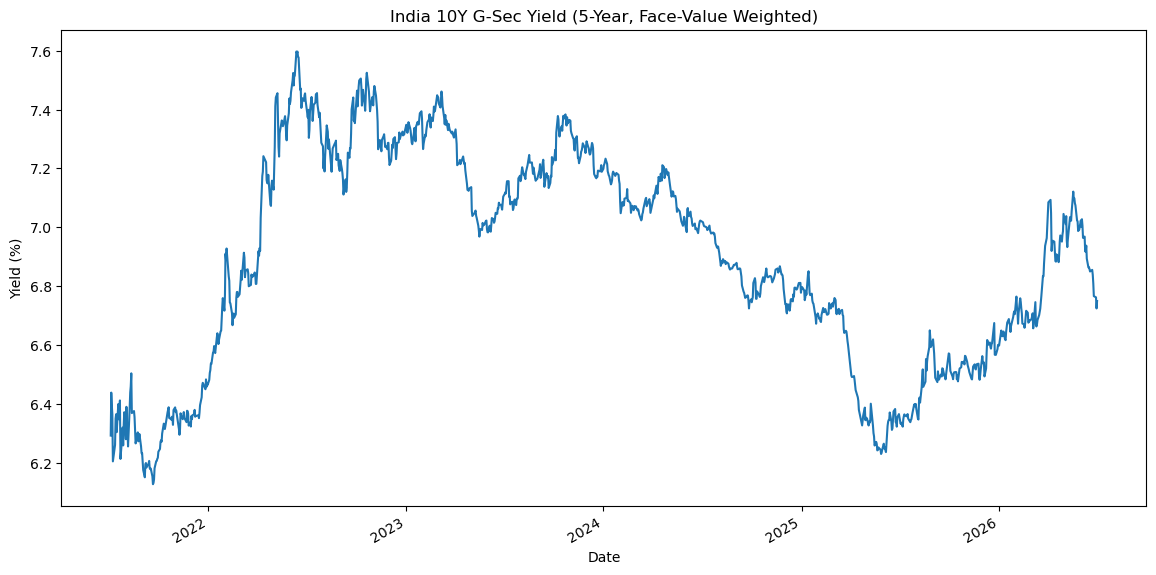

In [13]:
panel['10Y'].plot(figsize=(14,7), title='India 10Y G-Sec Yield (5-Year, Face-Value Weighted)', color='tab:blue')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.show()

In [14]:
india_10y = panel['10Y'].dropna()
india_10y.name = 'india_10y'
india_10y.head()
india_10y.tail()
print(f"{len(india_10y)} daily observations, {india_10y.index.min()} to {india_10y.index.max()}")

1201 daily observations, 2021-07-05 00:00:00 to 2026-07-01 00:00:00


In [15]:
print(panel.index.min(), panel.index.max())
print(panel.index.to_series().diff().value_counts().head(10))

2021-07-05 00:00:00 2026-07-01 00:00:00
trade_date
1 days    890
3 days    222
2 days     46
4 days     36
5 days      6
Name: count, dtype: int64


In [16]:
"""
Loader for RBI DBIE "Major Monetary Policy Rates" export.
Converts the sparse rate-change table into a clean daily repo rate series,
forward-filled and aligned to your G-Sec panel's date index.
"""

'\nLoader for RBI DBIE "Major Monetary Policy Rates" export.\nConverts the sparse rate-change table into a clean daily repo rate series,\nforward-filled and aligned to your G-Sec panel\'s date index.\n'

In [17]:
import pandas as pd


In [18]:
def load_repo_rate(path, target_index=None):
    raw = pd.read_excel(path, header=None)

    header_row_idx = raw[raw.apply(
        lambda row: row.astype(str).str.contains('Effective Date').any(), axis=1
    )].index[0]

    data = raw.iloc[header_row_idx + 3:].copy()
    data.columns = ['blank', 'eff_date', 'bank_rate', 'repo', 'reverse_repo',
                     'sdf', 'msf', 'crr', 'slr']
    data = data.drop(columns='blank')

    data['eff_date'] = pd.to_datetime(data['eff_date'], errors='coerce')
    data = data.dropna(subset=['eff_date'])

    data['repo'] = pd.to_numeric(data['repo'], errors='coerce')
    repo_changes = data[['eff_date', 'repo']].dropna().sort_values('eff_date')
    repo_changes = repo_changes.set_index('eff_date')['repo']
    repo_changes = repo_changes[~repo_changes.index.duplicated(keep='last')]

    if target_index is not None:
        full_range = pd.date_range(
            start=min(repo_changes.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        repo_daily = repo_changes.reindex(full_range).ffill()
        repo_daily = repo_daily.reindex(target_index)
    else:
        repo_daily = repo_changes

    repo_daily.name = 'repo_rate'
    return repo_daily

In [19]:
repo_daily = load_repo_rate(
    'data/5 year repo.xlsx',
    target_index=india_10y.index
)
repo_daily.head()
repo_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


trade_date
2026-06-24    5.25
2026-06-25    5.25
2026-06-29    5.25
2026-06-30    5.25
2026-07-01    5.25
Name: repo_rate, dtype: float64

In [20]:
repo_daily.isna().sum()

np.int64(0)

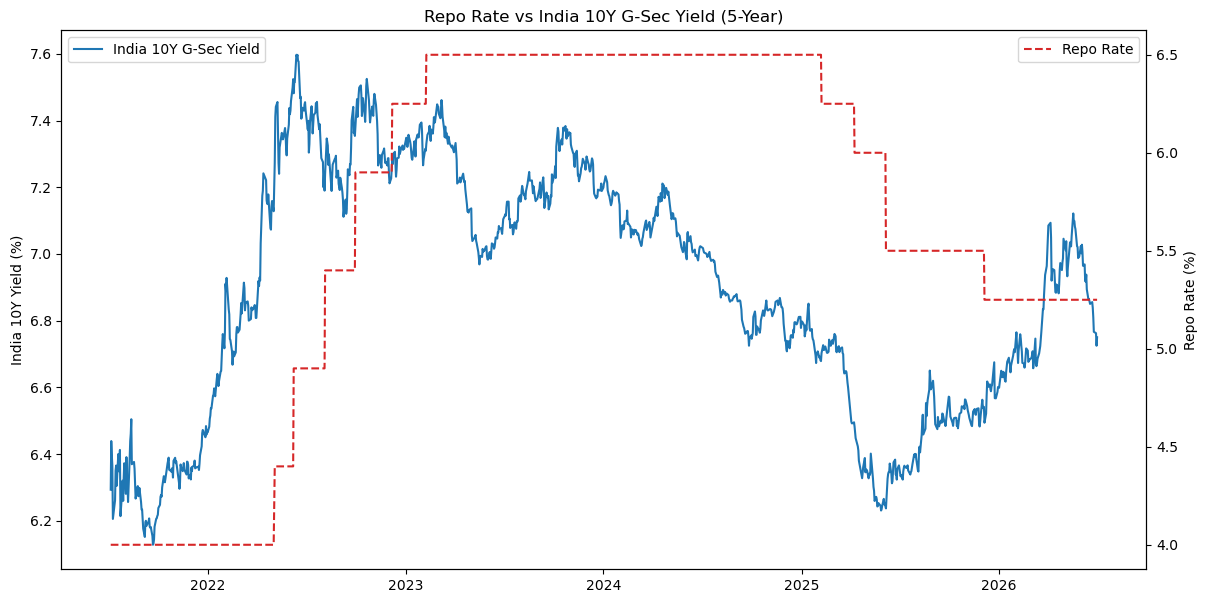

In [21]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(india_10y.index, india_10y, label='India 10Y G-Sec Yield', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(repo_daily.index, repo_daily, label='Repo Rate', color='tab:red', linestyle='--')
ax2.set_ylabel('Repo Rate (%)')
ax2.legend(loc='upper right')

plt.title('Repo Rate vs India 10Y G-Sec Yield (5-Year)')
plt.show()

In [22]:
print(repo_daily.head())
print(repo_daily.tail())

trade_date
2021-07-05    4.0
2021-07-06    4.0
2021-07-07    4.0
2021-07-08    4.0
2021-07-09    4.0
Name: repo_rate, dtype: float64
trade_date
2026-06-24    5.25
2026-06-25    5.25
2026-06-29    5.25
2026-06-30    5.25
2026-07-01    5.25
Name: repo_rate, dtype: float64


In [23]:
combined_df = pd.DataFrame({'india_10y': india_10y, 'repo_rate': repo_daily}).dropna()
print(combined_df.corr())

           india_10y  repo_rate
india_10y   1.000000   0.436314
repo_rate   0.436314   1.000000


In [24]:
"""
Loader for RBI DBIE "Monetary Survey" export -> clean M3 growth series,
aligned to your G-Sec panel's daily date index.
"""

'\nLoader for RBI DBIE "Monetary Survey" export -> clean M3 growth series,\naligned to your G-Sec panel\'s daily date index.\n'

In [25]:
def load_m3_growth(path, target_index=None, growth_periods=12):
    raw = pd.read_excel(path, header=None)

    date_col_parsed = pd.to_datetime(raw[1], errors='coerce')
    first_data_row = date_col_parsed.first_valid_index()

    data = raw.iloc[first_data_row:].copy()
    data = data[[1, 5]].copy()
    data.columns = ['date', 'm3']

    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['m3'] = pd.to_numeric(data['m3'], errors='coerce')
    data = data.dropna(subset=['date', 'm3']).sort_values('date')

    m3_level = data.set_index('date')['m3']
    m3_growth = m3_level.pct_change(periods=growth_periods) * 100
    m3_growth = m3_growth.dropna()

    if target_index is not None:
        full_range = pd.date_range(
            start=min(m3_growth.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        m3_daily = m3_growth.reindex(full_range).ffill()
        m3_daily = m3_daily.reindex(target_index)
    else:
        m3_daily = m3_growth

    m3_daily.name = 'm3_growth'
    return m3_daily

In [26]:
m3_daily = load_m3_growth(
    'data/Monetary Survey.xlsx',
    target_index=india_10y.index
)
m3_daily.head()
m3_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_20808\3589011357.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw[1], errors='coerce')


trade_date
2026-06-24    12.698547
2026-06-25    12.698547
2026-06-29    12.698547
2026-06-30    12.698547
2026-07-01    12.698547
Name: m3_growth, dtype: float64

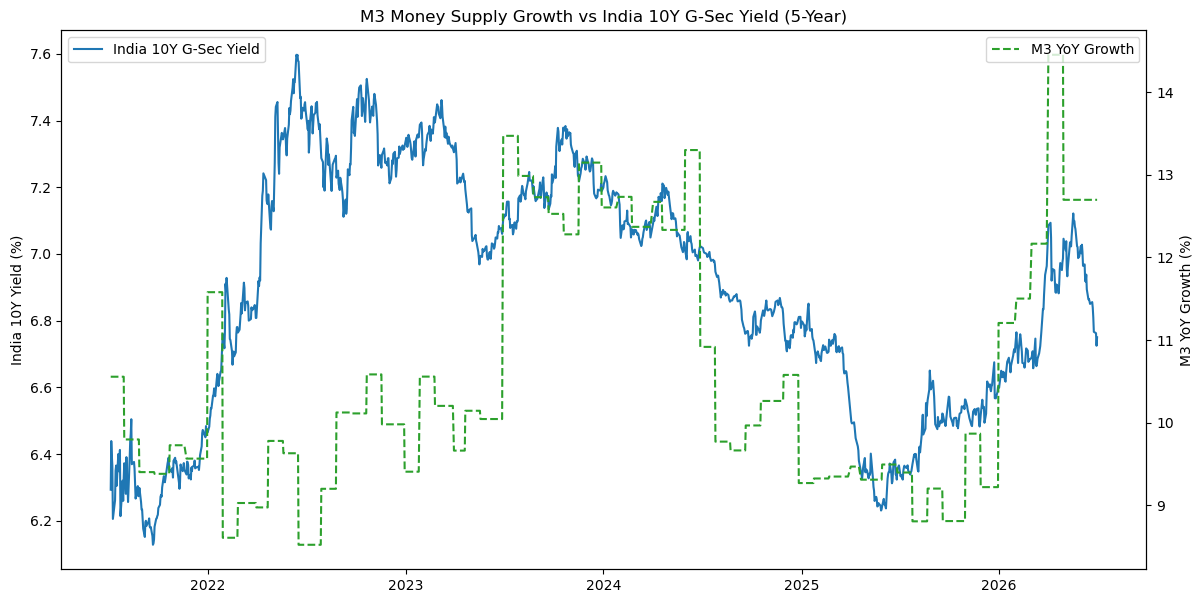

In [27]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(india_10y.index, india_10y, label='India 10Y G-Sec Yield', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(m3_daily.index, m3_daily, label='M3 YoY Growth', color='tab:green', linestyle='--')
ax2.set_ylabel('M3 YoY Growth (%)')
ax2.legend(loc='upper right')

plt.title('M3 Money Supply Growth vs India 10Y G-Sec Yield (5-Year)')
plt.show()

In [28]:
combined_m3 = pd.DataFrame({'india_10y': india_10y, 'm3_growth': m3_daily}).dropna()
print(combined_m3.corr())

           india_10y  m3_growth
india_10y   1.000000   0.340839
m3_growth   0.340839   1.000000


In [29]:
"""
Generic loader for FRED xlsx exports (works for DGS10, SOFR, or any other
FRED series downloaded in the same format). The FRED xlsx has two sheets:
'README' (metadata) and 'Daily' (actual data) -- always read from 'Daily'.
"""

"\nGeneric loader for FRED xlsx exports (works for DGS10, SOFR, or any other\nFRED series downloaded in the same format). The FRED xlsx has two sheets:\n'README' (metadata) and 'Daily' (actual data) -- always read from 'Daily'.\n"

In [30]:
def load_fred_series(path, column_name, target_index=None):
    raw = pd.read_excel(path, sheet_name='Daily')
    raw.columns = ['date', column_name]

    raw['date'] = pd.to_datetime(raw['date'], errors='coerce')
    raw[column_name] = pd.to_numeric(raw[column_name], errors='coerce')
    raw = raw.dropna(subset=['date']).sort_values('date').set_index('date')[column_name]

    if target_index is not None:
        full_range = pd.date_range(
            start=min(raw.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        daily = raw.reindex(full_range).ffill()
        daily = daily.reindex(target_index)
    else:
        daily = raw

    daily.name = column_name
    return daily

In [31]:
us10y_daily = load_fred_series(
    'data/DGS10.xlsx',
    column_name='us_10y',
    target_index=india_10y.index
)
us10y_daily.head()
us10y_daily.tail()

trade_date
2026-06-24    4.41
2026-06-25    4.40
2026-06-29    4.38
2026-06-30    4.44
2026-07-01    4.44
Name: us_10y, dtype: float64

In [32]:
sofr_daily = load_fred_series(
    'data/SOFR.xlsx',
    column_name='sofr',
    target_index=india_10y.index
)
sofr_daily.head()
sofr_daily.tail()

trade_date
2026-06-24    3.62
2026-06-25    3.64
2026-06-29    3.62
2026-06-30    3.68
2026-07-01    3.66
Name: sofr, dtype: float64

In [33]:
print("us10y_daily NaNs:", us10y_daily.isna().sum())
print("sofr_daily NaNs:", sofr_daily.isna().sum())

us10y_daily NaNs: 1
sofr_daily NaNs: 0


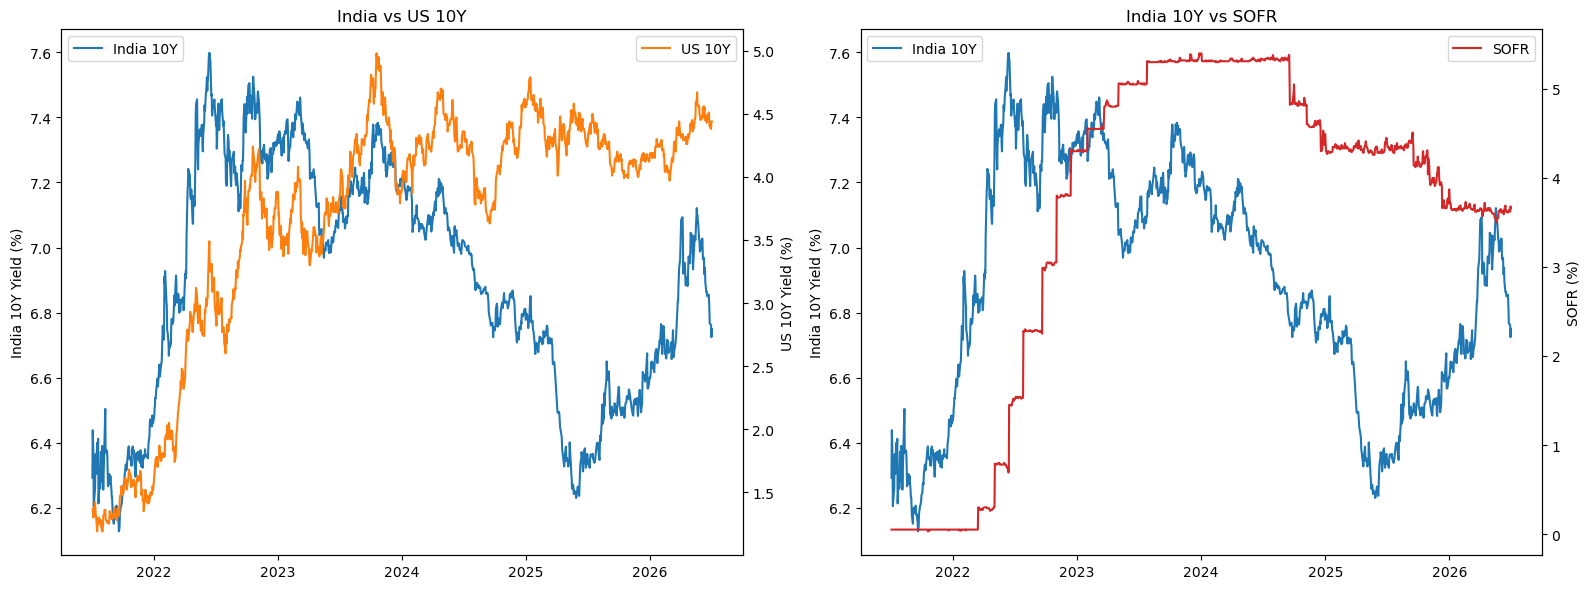

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
axes[0].set_ylabel('India 10Y Yield (%)')
axes[0].legend(loc='upper left')
ax0b = axes[0].twinx()
ax0b.plot(us10y_daily.index, us10y_daily, label='US 10Y', color='tab:orange')
ax0b.set_ylabel('US 10Y Yield (%)')
ax0b.legend(loc='upper right')
axes[0].set_title('India vs US 10Y')

axes[1].plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
axes[1].set_ylabel('India 10Y Yield (%)')
axes[1].legend(loc='upper left')
ax1b = axes[1].twinx()
ax1b.plot(sofr_daily.index, sofr_daily, label='SOFR', color='tab:red')
ax1b.set_ylabel('SOFR (%)')
ax1b.legend(loc='upper right')
axes[1].set_title('India 10Y vs SOFR')

plt.tight_layout()
plt.show()

In [35]:
"""
Loader for NSE India VIX historical data export.
Converts the 1-year CSV/xlsx chunks into a clean daily India VIX series,
forward-filled and aligned to your G-Sec panel's date index.
"""

"\nLoader for NSE India VIX historical data export.\nConverts the 1-year CSV/xlsx chunks into a clean daily India VIX series,\nforward-filled and aligned to your G-Sec panel's date index.\n"

In [36]:
vix_files = [
    'data/hist_india_vix_-01-07-2021-to-30-06-2022.csv',
    'data/hist_india_vix_-01-07-2022-to-30-06-2023.csv',
    'data/hist_india_vix_-01-07-2023-to-30-06-2024.csv',
    'data/hist_india_vix_-01-07-2024-to-30-06-2025.csv',
    'data/hist_india_vix_-01-07-2025-to-01-07-2026.csv',

]

In [37]:
def load_india_vix(paths, target_index=None):
    """
    paths: list of csv file paths (one per 1-year NSE India VIX export chunk)
    """
    chunks = []
    for path in paths:
        raw = pd.read_csv(path, encoding='utf-8-sig')
        raw.columns = [c.strip() for c in raw.columns]
        chunks.append(raw[['Date', 'Close']])

    data = pd.concat(chunks, ignore_index=True)
    data.columns = ['date', 'india_vix']

    data['date'] = pd.to_datetime(data['date'], format='%d-%b-%Y', errors='coerce')
    data['india_vix'] = pd.to_numeric(data['india_vix'], errors='coerce')
    data = data.dropna(subset=['date']).sort_values('date')
    data = data.drop_duplicates(subset='date', keep='last')

    vix_level = data.set_index('date')['india_vix']

    if target_index is not None:
        full_range = pd.date_range(
            start=min(vix_level.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        vix_daily = vix_level.reindex(full_range).ffill()
        vix_daily = vix_daily.reindex(target_index)
    else:
        vix_daily = vix_level

    vix_daily.name = 'india_vix'
    return vix_daily

In [38]:
india_vix_daily = load_india_vix(vix_files, target_index=india_10y.index)
india_vix_daily.head()
india_vix_daily.tail()

trade_date
2026-06-24    13.39
2026-06-25    13.05
2026-06-29    13.61
2026-06-30    13.60
2026-07-01    13.24
Name: india_vix, dtype: float64

In [39]:
print("india_vix_daily NaNs:", india_vix_daily.isna().sum())

india_vix_daily NaNs: 0


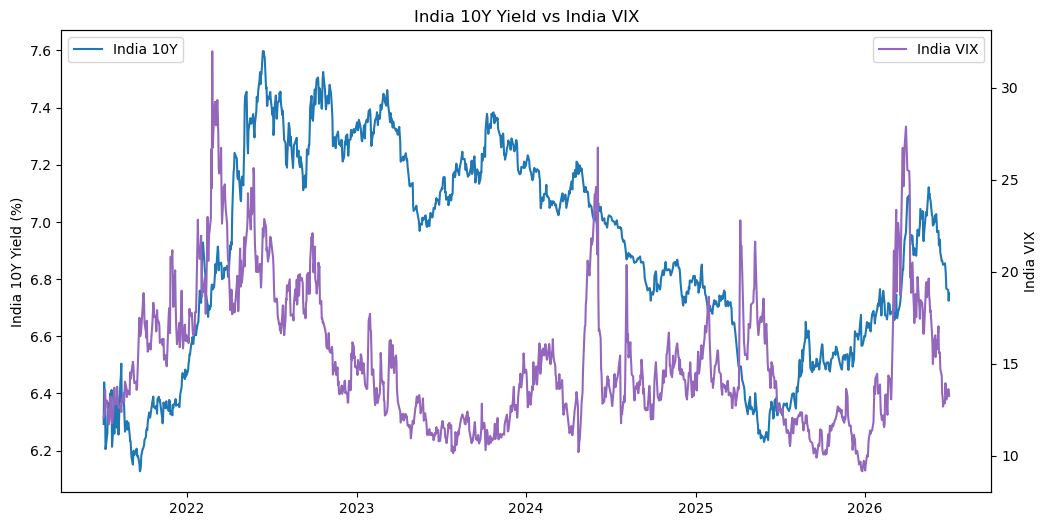

In [40]:
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(india_vix_daily.index, india_vix_daily, label='India VIX', color='tab:purple')
ax2.set_ylabel('India VIX')
ax2.legend(loc='upper right')

plt.title('India 10Y Yield vs India VIX')
plt.show()

In [41]:
corr_vix = india_10y.corr(india_vix_daily)
print(f"Correlation (India 10Y vs India VIX): {corr_vix:.4f}")

Correlation (India 10Y vs India VIX): 0.1194


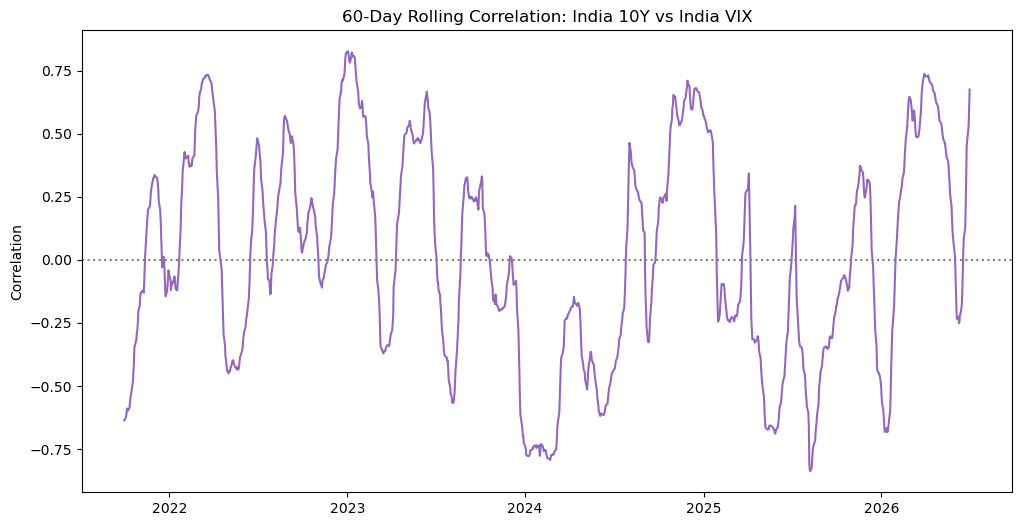

In [42]:
rolling_corr = india_10y.rolling(60).corr(india_vix_daily)

plt.figure(figsize=(12,6))
plt.plot(rolling_corr.index, rolling_corr, color='tab:purple')
plt.axhline(0, color='gray', linestyle=':')
plt.title('60-Day Rolling Correlation: India 10Y vs India VIX')
plt.ylabel('Correlation')
plt.show()

In [43]:
combo = pd.DataFrame({
    'india_10y': india_10y,
    'repo': repo_daily,
    'm3_growth': m3_daily,
    'us_10y': us10y_daily,
    'sofr': sofr_daily,
    'india_vix': india_vix_daily,
})

corr_matrix = combo.corr()
print(corr_matrix['india_10y'].sort_values(ascending=False))

india_10y    1.000000
repo         0.436314
m3_growth    0.340839
sofr         0.311671
us_10y       0.290932
india_vix    0.119382
Name: india_10y, dtype: float64


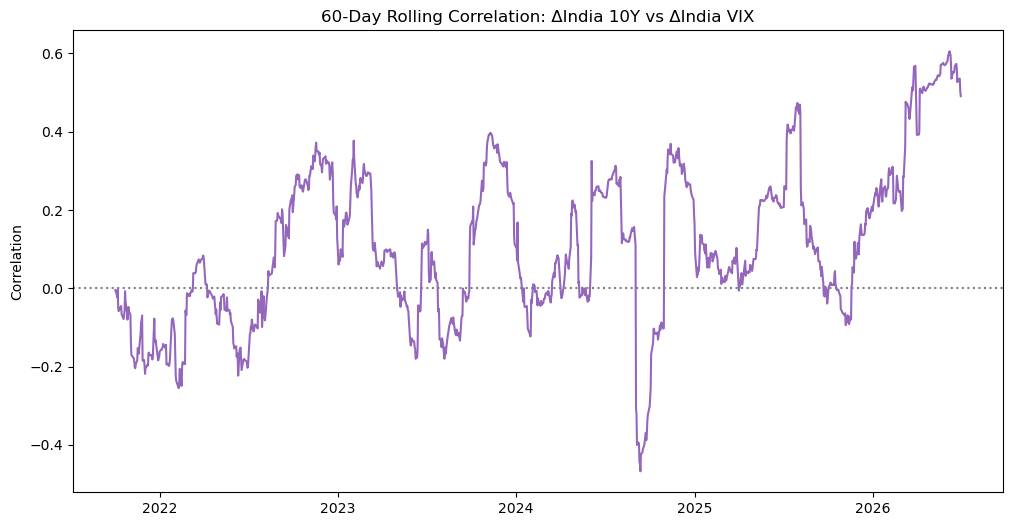

In [44]:
india_10y_chg = india_10y.diff()
india_vix_chg = india_vix_daily.diff()

rolling_corr_chg = india_10y_chg.rolling(60).corr(india_vix_chg)

plt.figure(figsize=(12,6))
plt.plot(rolling_corr_chg.index, rolling_corr_chg, color='tab:purple')
plt.axhline(0, color='gray', linestyle=':')
plt.title('60-Day Rolling Correlation: ΔIndia 10Y vs ΔIndia VIX')
plt.ylabel('Correlation')
plt.show()

In [45]:
"""
Loader for CPI (Combined) inflation data.
Converts the monthly YoY % series into a clean daily CPI series,
forward-filled and aligned to your G-Sec panel's date index.
"""

"\nLoader for CPI (Combined) inflation data.\nConverts the monthly YoY % series into a clean daily CPI series,\nforward-filled and aligned to your G-Sec panel's date index.\n"

In [46]:
def load_cpi(path, target_index=None):
    raw = pd.read_csv(path)
    raw = raw[(raw['state'] == 'All India') & (raw['sector'] == 'Combined')].copy()
    raw = raw[['year', 'month_code', 'inflation']].copy()
    raw['date'] = pd.to_datetime(raw['year'].astype(str) + '-' + raw['month_code'].astype(str) + '-01')
    raw = raw.dropna(subset=['inflation']).sort_values('date')

    cpi_level = raw.set_index('date')['inflation']

    if target_index is not None:
        full_range = pd.date_range(
            start=min(cpi_level.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        cpi_daily = cpi_level.reindex(full_range).ffill()
        cpi_daily = cpi_daily.reindex(target_index)
    else:
        cpi_daily = cpi_level

    cpi_daily.name = 'cpi'
    return cpi_daily

In [47]:
cpi_daily = load_cpi('data/viz_data (1).csv', target_index=india_10y.index)
cpi_daily.head()
cpi_daily.tail()

trade_date
2026-06-24    1.33
2026-06-25    1.33
2026-06-29    1.33
2026-06-30    1.33
2026-07-01    1.33
Name: cpi, dtype: float64

cpi_daily NaNs: 0


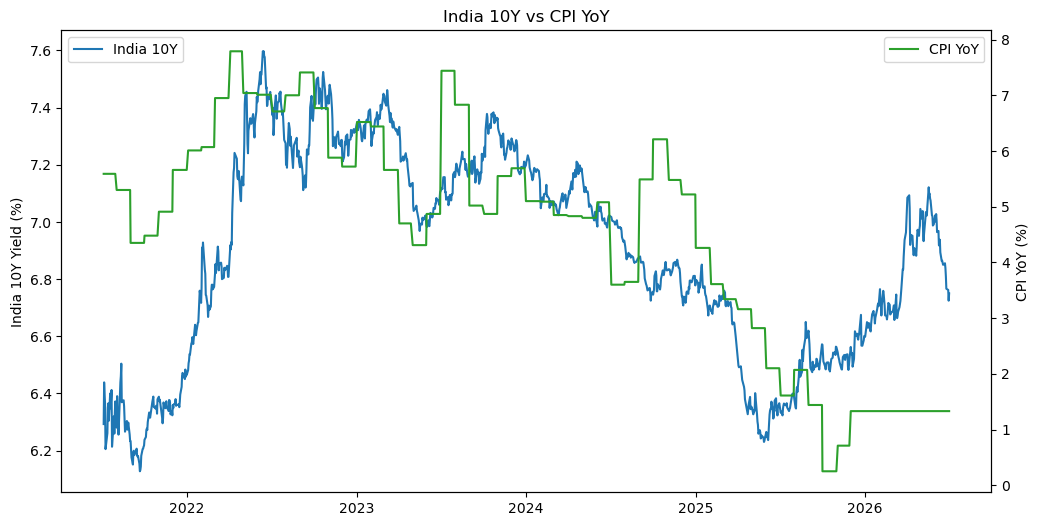

Corr (Δ10Y vs ΔCPI): 0.04107261052704458


In [48]:
print("cpi_daily NaNs:", cpi_daily.isna().sum())

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(cpi_daily.index, cpi_daily, label='CPI YoY', color='tab:green')
ax2.set_ylabel('CPI YoY (%)')
ax2.legend(loc='upper right')
plt.title('India 10Y vs CPI YoY')
plt.show()

print("Corr (Δ10Y vs ΔCPI):", india_10y.diff().corr(cpi_daily.diff()))

In [49]:
"""
Loader for WPI inflation data.
Converts the monthly YoY % series into a clean daily WPI series,
forward-filled and aligned to your G-Sec panel's date index.
"""

"\nLoader for WPI inflation data.\nConverts the monthly YoY % series into a clean daily WPI series,\nforward-filled and aligned to your G-Sec panel's date index.\n"

In [50]:
def load_wpi(path, target_index=None):
    raw = pd.read_excel(path, header=None)

    month_row = raw.iloc[5]
    type_row = raw.iloc[6]
    data_row = raw[raw[1].astype(str).str.strip() == 'ALL COMMODITIES'].iloc[0]

    records = {}
    for col in range(3, raw.shape[1]):
        month_label = month_row[col]
        if pd.isna(month_label):
            continue
        month_label = str(month_label).strip()
        type_label = str(type_row[col]).strip() if pd.notna(type_row[col]) else 'Final'
        val = data_row[col]
        records.setdefault(month_label, {})[type_label] = val

    final_vals = {}
    for month_label, vals in records.items():
        if 'Final' in vals and pd.notna(vals['Final']):
            final_vals[month_label] = vals['Final']
        elif 'Provisional' in vals:
            final_vals[month_label] = vals['Provisional']

    wpi_level = pd.Series(final_vals)
    wpi_level.index = pd.to_datetime(wpi_level.index, format='%b-%Y', errors='coerce')
    wpi_level = wpi_level[wpi_level.index.notna()].sort_index()

    # drop the base-year placeholder zeros (no real YoY figure yet)
    wpi_level = wpi_level[~((wpi_level == 0) & (wpi_level.index < '2012-06-01'))]

    if target_index is not None:
        full_range = pd.date_range(
            start=min(wpi_level.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        wpi_daily = wpi_level.reindex(full_range).ffill()
        wpi_daily = wpi_daily.reindex(target_index)
    else:
        wpi_daily = wpi_level

    wpi_daily.name = 'wpi'
    return wpi_daily

In [51]:
wpi_daily = load_wpi('data/Wholesale Price Index - Monthly Data .xlsx', target_index=india_10y.index)
wpi_daily.head()
wpi_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


trade_date
2026-06-24    8.300908
2026-06-25    8.300908
2026-06-29    8.300908
2026-06-30    8.300908
2026-07-01    8.300908
Name: wpi, dtype: float64

In [52]:
print(wpi_daily.value_counts().head(10))

wpi
8.300908     60
2.513228     23
14.274322    23
16.230366    22
2.754098     22
5.024424     22
10.553130    22
0.963391     22
0.193924     21
14.626636    21
Name: count, dtype: int64


wpi_daily NaNs: 0


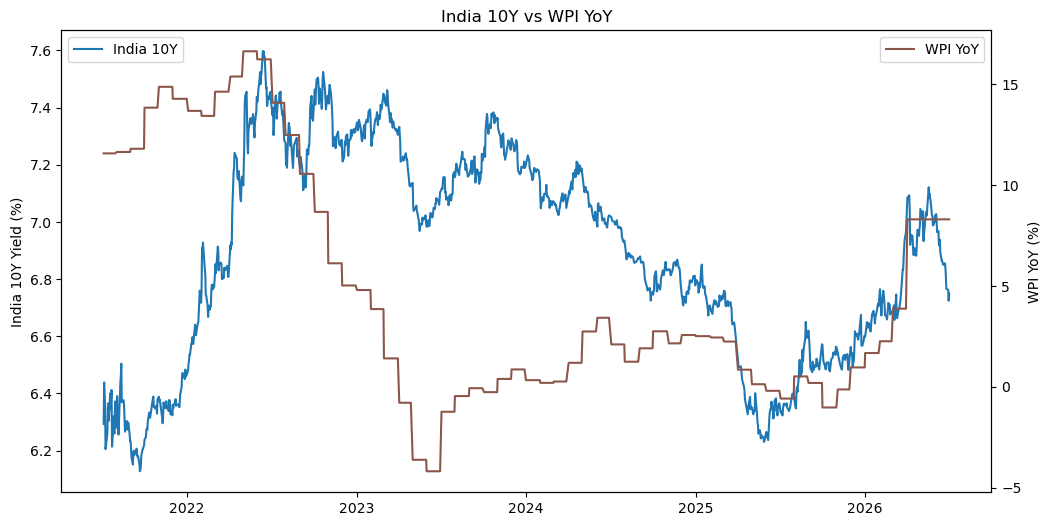

Corr (Δ10Y vs ΔWPI): 0.08451298638739323


In [53]:
print("wpi_daily NaNs:", wpi_daily.isna().sum())

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(wpi_daily.index, wpi_daily, label='WPI YoY', color='tab:brown')
ax2.set_ylabel('WPI YoY (%)')
ax2.legend(loc='upper right')
plt.title('India 10Y vs WPI YoY')
plt.show()

print("Corr (Δ10Y vs ΔWPI):", india_10y.diff().corr(wpi_daily.diff()))

In [54]:
"""
Loader for RBI DBIE "Exchange Rate of the Indian Rupee..." export.
Extracts the US Dollar End-month spot rate and forward-fills to daily,
aligned to your G-Sec panel's date index.
"""

'\nLoader for RBI DBIE "Exchange Rate of the Indian Rupee..." export.\nExtracts the US Dollar End-month spot rate and forward-fills to daily,\naligned to your G-Sec panel\'s date index.\n'

In [55]:
def load_usdinr(path, target_index=None):
    raw = pd.read_excel(path, header=None)
    date_col_parsed = pd.to_datetime(raw[1], errors='coerce')
    first_data_row = date_col_parsed.first_valid_index()

    data = raw.iloc[first_data_row:].copy()
    data = data[[1, 6]].copy()  # col1 = date, col6 = US Dollar End-month
    data.columns = ['date', 'usdinr']

    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['usdinr'] = pd.to_numeric(data['usdinr'], errors='coerce')
    data = data.dropna(subset=['date', 'usdinr']).sort_values('date')

    usdinr_level = data.set_index('date')['usdinr']

    if target_index is not None:
        full_range = pd.date_range(
            start=min(usdinr_level.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        usdinr_daily = usdinr_level.reindex(full_range).ffill()
        usdinr_daily = usdinr_daily.reindex(target_index)
    else:
        usdinr_daily = usdinr_level

    usdinr_daily.name = 'usdinr'
    return usdinr_daily

In [56]:
usdinr_daily = load_usdinr(
    'data/USD INR spot rates.xlsx',
    target_index=india_10y.index
)
usdinr_daily.head()
usdinr_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_20808\3694052605.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw[1], errors='coerce')


trade_date
2026-06-24    95.3845
2026-06-25    95.3845
2026-06-29    95.3845
2026-06-30    94.5975
2026-07-01    94.5975
Name: usdinr, dtype: float64

usdinr_daily NaNs: 0


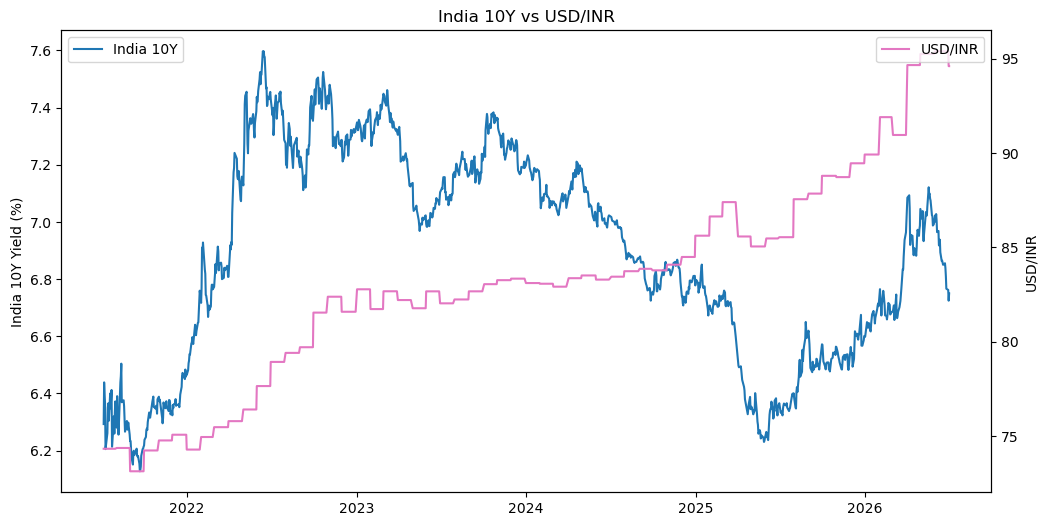

Corr (Δ10Y vs ΔUSDINR): 0.11750638068517716


In [57]:
print("usdinr_daily NaNs:", usdinr_daily.isna().sum())

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(india_10y.index, india_10y, label='India 10Y', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(usdinr_daily.index, usdinr_daily, label='USD/INR', color='tab:pink')
ax2.set_ylabel('USD/INR')
ax2.legend(loc='upper right')
plt.title('India 10Y vs USD/INR')
plt.show()

print("Corr (Δ10Y vs ΔUSDINR):", india_10y.diff().corr(usdinr_daily.diff()))

In [58]:
from scipy import stats

chg_10y = india_10y.diff().dropna()
chg_usdinr = usdinr_daily.diff().dropna()

aligned = pd.concat([chg_10y, chg_usdinr], axis=1).dropna()
r, p = stats.pearsonr(aligned.iloc[:,0], aligned.iloc[:,1])
print(f"r = {r:.4f}, p-value = {p:.6f}, n = {len(aligned)}")

r = 0.1175, p-value = 0.000045, n = 1200


In [59]:
final_matrix = india_10y.to_frame('india_10y').join([
    repo_daily,
    m3_daily,
    us10y_daily,
    sofr_daily,
    india_vix_daily,
    usdinr_daily,
    cpi_daily,
    wpi_daily,
])

final_matrix.head()
final_matrix.tail()

,india_10y,repo_rate,m3_growth,us_10y,sofr,india_vix,usdinr,cpi,wpi
trade_date,,,,,,,,,
2026-06-24,6.809441,5.25,12.698547,4.41,3.62,13.39,95.3845,1.33,8.300908
2026-06-25,6.766475,5.25,12.698547,4.40,3.64,13.05,95.3845,1.33,8.300908
2026-06-29,6.762209,5.25,12.698547,4.38,3.62,13.61,95.3845,1.33,8.300908
2026-06-30,6.724646,5.25,12.698547,4.44,3.68,13.60,94.5975,1.33,8.300908
2026-07-01,6.749750,5.25,12.698547,4.44,3.66,13.24,94.5975,1.33,8.300908


In [60]:
print("Missing values per column (daily):")
print(final_matrix.isna().sum())

Missing values per column (daily):
india_10y    0
repo_rate    0
m3_growth    0
us_10y       1
sofr         0
india_vix    0
usdinr       0
cpi          0
wpi          0
dtype: int64


In [61]:
weekly_matrix = final_matrix.resample('W-FRI').last()
weekly_matrix.head()
weekly_matrix.tail()
print("\nMissing values per column (weekly):")
print(weekly_matrix.isna().sum())


Missing values per column (weekly):
india_10y    0
repo_rate    0
m3_growth    0
us_10y       0
sofr         0
india_vix    0
usdinr       0
cpi          0
wpi          0
dtype: int64


In [62]:
weekly_matrix = weekly_matrix.dropna()
print(f"\nFinal weekly panel shape: {weekly_matrix.shape}")


Final weekly panel shape: (261, 9)


In [63]:
weekly_standardized = (weekly_matrix - weekly_matrix.mean()) / weekly_matrix.std()
weekly_standardized.head()

,india_10y,repo_rate,m3_growth,us_10y,sofr,india_vix,usdinr,cpi,wpi
trade_date,,,,,,,,,
2021-07-09,-1.879510,-1.811945,-0.011343,-2.343121,-1.919112,-0.551415,-1.639673,0.529485,1.176028
2021-07-16,-1.608219,-1.811945,-0.011343,-2.404484,-1.919112,-0.892284,-1.639673,0.529485,1.176028
2021-07-23,-1.856703,-1.811945,-0.011343,-2.414711,-1.919112,-0.876446,-1.639673,0.529485,1.176028
2021-07-30,-1.422743,-1.811945,-0.514793,-2.476074,-1.919112,-0.589978,-1.639673,0.529485,1.176028
2021-08-06,-1.740694,-1.811945,-0.514793,-2.404484,-1.919112,-0.643691,-1.631857,0.384856,1.188002


In [64]:
corr_based_cov = weekly_standardized.cov()
corr_based_cov

,india_10y,repo_rate,m3_growth,us_10y,sofr,india_vix,usdinr,cpi,wpi
india_10y,1.000000,0.441517,0.341333,0.290921,0.315046,0.109171,-0.009798,0.542515,-0.016034
repo_rate,0.441517,1.000000,0.361089,0.792438,0.951571,-0.453597,0.448316,-0.012693,-0.819855
m3_growth,0.341333,0.361089,1.000000,0.385004,0.425556,-0.128784,0.341988,-0.041972,-0.277044
us_10y,0.290921,0.792438,0.385004,1.000000,0.880054,-0.323188,0.802984,-0.401604,-0.750510
sofr,0.315046,0.951571,0.425556,0.880054,1.000000,-0.517890,0.630144,-0.258797,-0.905004
india_vix,0.109171,-0.453597,-0.128784,-0.323188,-0.517890,1.000000,-0.264811,0.271656,0.659599
usdinr,-0.009798,0.448316,0.341988,0.802984,0.630144,-0.264811,1.000000,-0.750687,-0.570323
cpi,0.542515,-0.012693,-0.041972,-0.401604,-0.258797,0.271656,-0.750687,1.000000,0.411196
wpi,-0.016034,-0.819855,-0.277044,-0.750510,-0.905004,0.659599,-0.570323,0.411196,1.000000


In [65]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(corr_based_cov)

sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues:", eigenvalues)
print("\nVariance explained by each component:")
variance_explained = eigenvalues / eigenvalues.sum() * 100
for i, v in enumerate(variance_explained):
    print(f"PC{i+1}: {v:.2f}%")

Eigenvalues: [4.75231874 1.92577769 1.06694988 0.69453879 0.33769031 0.10725005
 0.06414231 0.04019971 0.01113253]

Variance explained by each component:
PC1: 52.80%
PC2: 21.40%
PC3: 11.85%
PC4: 7.72%
PC5: 3.75%
PC6: 1.19%
PC7: 0.71%
PC8: 0.45%
PC9: 0.12%


In [66]:
import pandas as pd

n_components = 5
loadings = pd.DataFrame(
    eigenvectors[:, :n_components],
    index=weekly_matrix.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings

,PC1,PC2,PC3,PC4,PC5
india_10y,-0.100830,-0.633326,-0.173883,-0.153940,0.566491
repo_rate,-0.400066,-0.263948,0.191082,-0.173358,-0.255553
m3_growth,-0.215575,-0.234694,-0.425909,0.818538,-0.203493
us_10y,-0.421746,-0.030154,-0.204992,-0.272552,0.026917
sofr,-0.443486,-0.117728,0.092986,-0.091367,-0.189932
india_vix,0.263181,-0.144509,-0.608683,-0.421008,-0.565328
usdinr,-0.353994,0.263947,-0.428289,-0.127631,0.323853
cpi,0.200495,-0.602210,0.253156,-0.005410,-0.131042
wpi,0.417114,-0.078562,-0.288395,0.006755,0.306470


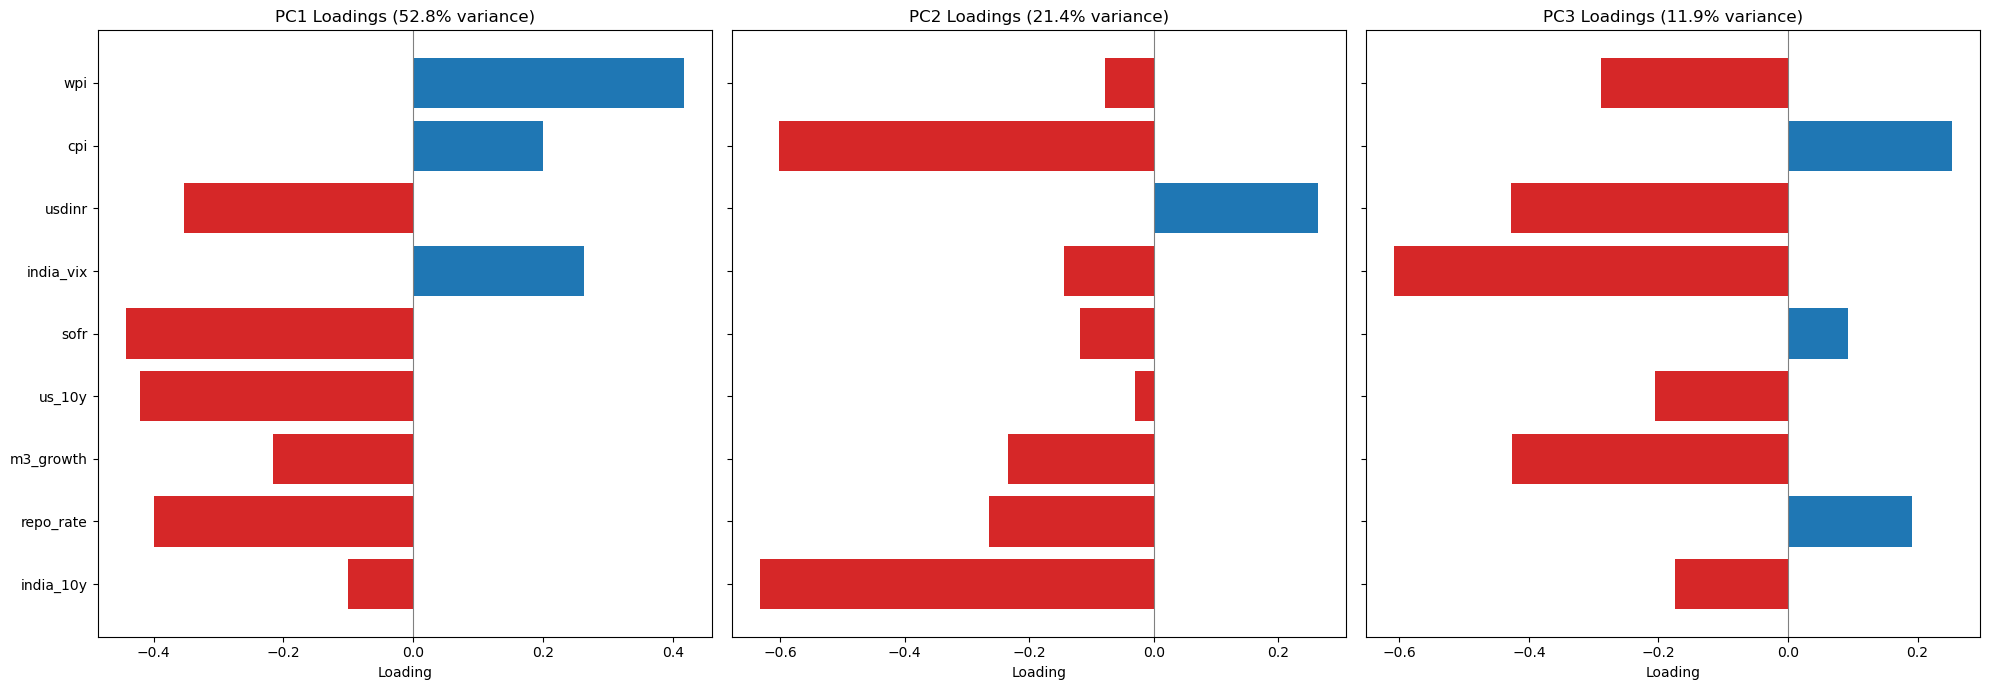

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    colors = ['tab:blue' if v >= 0 else 'tab:red' for v in loadings[pc]]
    axes[i].barh(loadings.index, loadings[pc], color=colors)
    axes[i].axvline(0, color='gray', linewidth=0.8)
    axes[i].set_title(f'{pc} Loadings ({variance_explained[i]:.1f}% variance)')
    axes[i].set_xlabel('Loading')

plt.tight_layout()
plt.show()

In [68]:
pc_scores = weekly_standardized.values @ eigenvectors[:, :3]
pc_scores = pd.DataFrame(pc_scores, index=weekly_standardized.index, columns=['PC1', 'PC2', 'PC3'])
pc_scores.head()
pc_scores.tail()

,PC1,PC2,PC3
trade_date,,,
2026-06-05,-1.364020,1.124682,-2.620210
2026-06-12,-1.396701,1.290672,-2.391490
2026-06-19,-1.496028,1.436301,-2.075240
2026-06-26,-1.445747,1.580750,-2.034689
2026-07-03,-1.396958,1.560539,-2.002486


In [69]:
# align india_10y to the same weekly index as pc_scores
india_10y_weekly = india_10y.resample('W-FRI').last().reindex(pc_scores.index)

print("Correlation: India 10Y (weekly) vs each PC score")
for col in pc_scores.columns:
    print(f"  {col}: {india_10y_weekly.corr(pc_scores[col]):.4f}")

Correlation: India 10Y (weekly) vs each PC score
  PC1: -0.2198
  PC2: -0.8789
  PC3: -0.1796


In [70]:
print(corr_based_cov['india_10y'].sort_values(ascending=False))

india_10y    1.000000
cpi          0.542515
repo_rate    0.441517
m3_growth    0.341333
sofr         0.315046
us_10y       0.290921
india_vix    0.109171
usdinr      -0.009798
wpi         -0.016034
Name: india_10y, dtype: float64


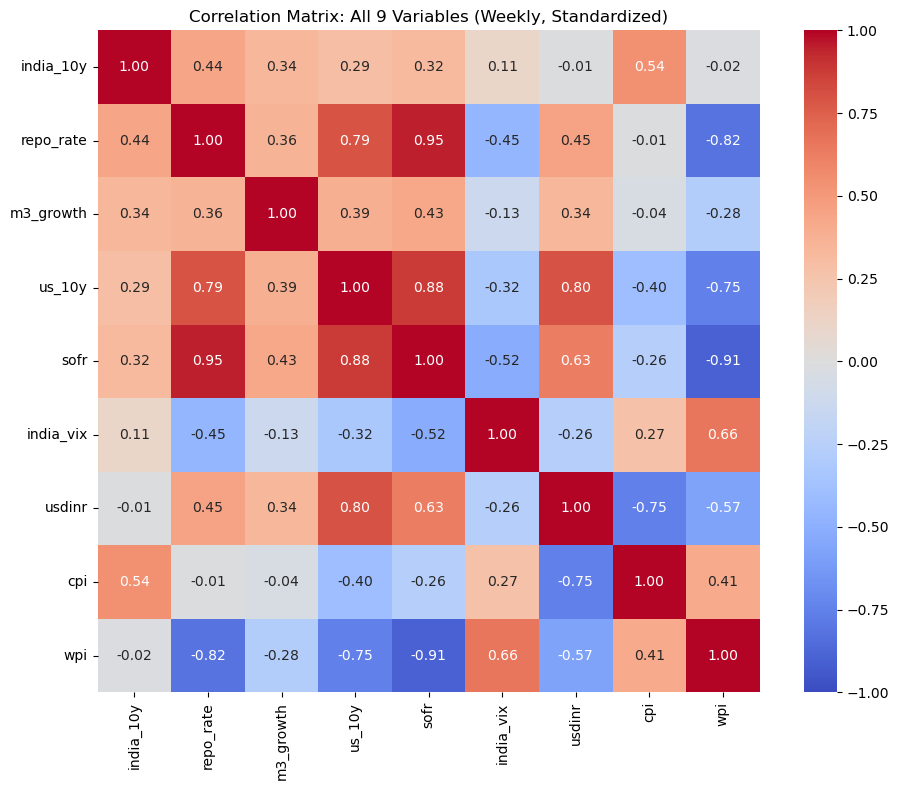

In [71]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_based_cov, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: All 9 Variables (Weekly, Standardized)')
plt.tight_layout()
plt.show()

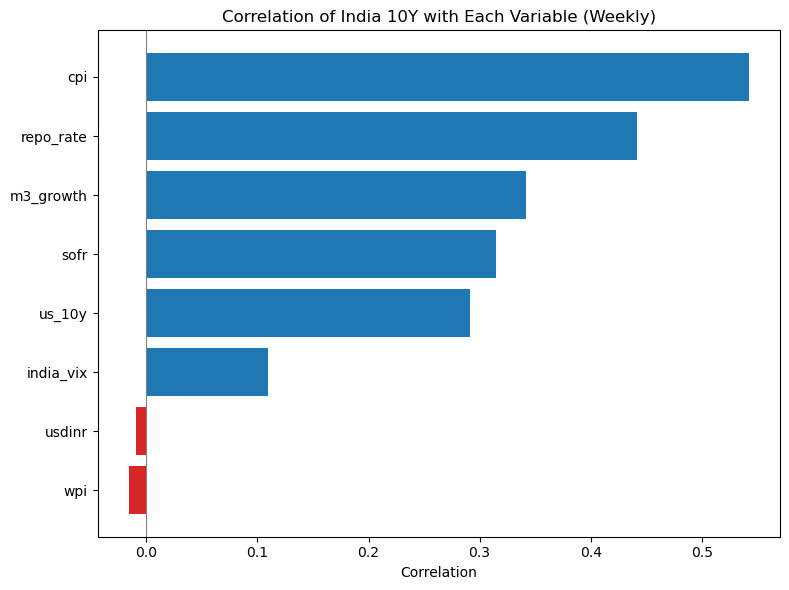

In [72]:
corr_with_10y = corr_based_cov['india_10y'].drop('india_10y').sort_values()

plt.figure(figsize=(8,6))
colors = ['tab:red' if v < 0 else 'tab:blue' for v in corr_with_10y]
plt.barh(corr_with_10y.index, corr_with_10y.values, color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Correlation of India 10Y with Each Variable (Weekly)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

In [73]:
predictors_standardized = weekly_standardized.drop(columns=['india_10y'])
predictors_standardized.head()

,repo_rate,m3_growth,us_10y,sofr,india_vix,usdinr,cpi,wpi
trade_date,,,,,,,,
2021-07-09,-1.811945,-0.011343,-2.343121,-1.919112,-0.551415,-1.639673,0.529485,1.176028
2021-07-16,-1.811945,-0.011343,-2.404484,-1.919112,-0.892284,-1.639673,0.529485,1.176028
2021-07-23,-1.811945,-0.011343,-2.414711,-1.919112,-0.876446,-1.639673,0.529485,1.176028
2021-07-30,-1.811945,-0.514793,-2.476074,-1.919112,-0.589978,-1.639673,0.529485,1.176028
2021-08-06,-1.811945,-0.514793,-2.404484,-1.919112,-0.643691,-1.631857,0.384856,1.188002


In [74]:
predictors_cov = predictors_standardized.cov()
predictors_cov

,repo_rate,m3_growth,us_10y,sofr,india_vix,usdinr,cpi,wpi
repo_rate,1.000000,0.361089,0.792438,0.951571,-0.453597,0.448316,-0.012693,-0.819855
m3_growth,0.361089,1.000000,0.385004,0.425556,-0.128784,0.341988,-0.041972,-0.277044
us_10y,0.792438,0.385004,1.000000,0.880054,-0.323188,0.802984,-0.401604,-0.750510
sofr,0.951571,0.425556,0.880054,1.000000,-0.517890,0.630144,-0.258797,-0.905004
india_vix,-0.453597,-0.128784,-0.323188,-0.517890,1.000000,-0.264811,0.271656,0.659599
usdinr,0.448316,0.341988,0.802984,0.630144,-0.264811,1.000000,-0.750687,-0.570323
cpi,-0.012693,-0.041972,-0.401604,-0.258797,0.271656,-0.750687,1.000000,0.411196
wpi,-0.819855,-0.277044,-0.750510,-0.905004,0.659599,-0.570323,0.411196,1.000000


In [75]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(predictors_cov)

sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues:", eigenvalues)
print("\nVariance explained by each component:")
variance_explained = eigenvalues / eigenvalues.sum() * 100
for i, v in enumerate(variance_explained):
    print(f"PC{i+1}: {v:.2f}%")

Eigenvalues: [4.7156981  1.31754775 0.98841405 0.66952533 0.19062957 0.06625875
 0.04029041 0.01163602]

Variance explained by each component:
PC1: 58.95%
PC2: 16.47%
PC3: 12.36%
PC4: 8.37%
PC5: 2.38%
PC6: 0.83%
PC7: 0.50%
PC8: 0.15%


In [76]:
import pandas as pd

n_components = 5
loadings = pd.DataFrame(
    eigenvectors[:, :n_components],
    index=predictors_standardized.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings

,PC1,PC2,PC3,PC4,PC5
repo_rate,-0.393520,-0.393114,0.014872,-0.256852,-0.034745
m3_growth,-0.208926,-0.191495,-0.665217,0.675580,-0.117776
us_10y,-0.420624,0.035347,-0.193345,-0.313933,0.365357
sofr,-0.441353,-0.201751,-0.003663,-0.142554,-0.123674
india_vix,0.270130,0.087365,-0.625039,-0.577412,-0.435961
usdinr,-0.360863,0.455861,-0.229556,-0.084419,0.412266
cpi,0.219314,-0.738207,-0.087868,-0.134952,0.366898
wpi,0.422474,0.080291,-0.262257,0.000509,0.584381


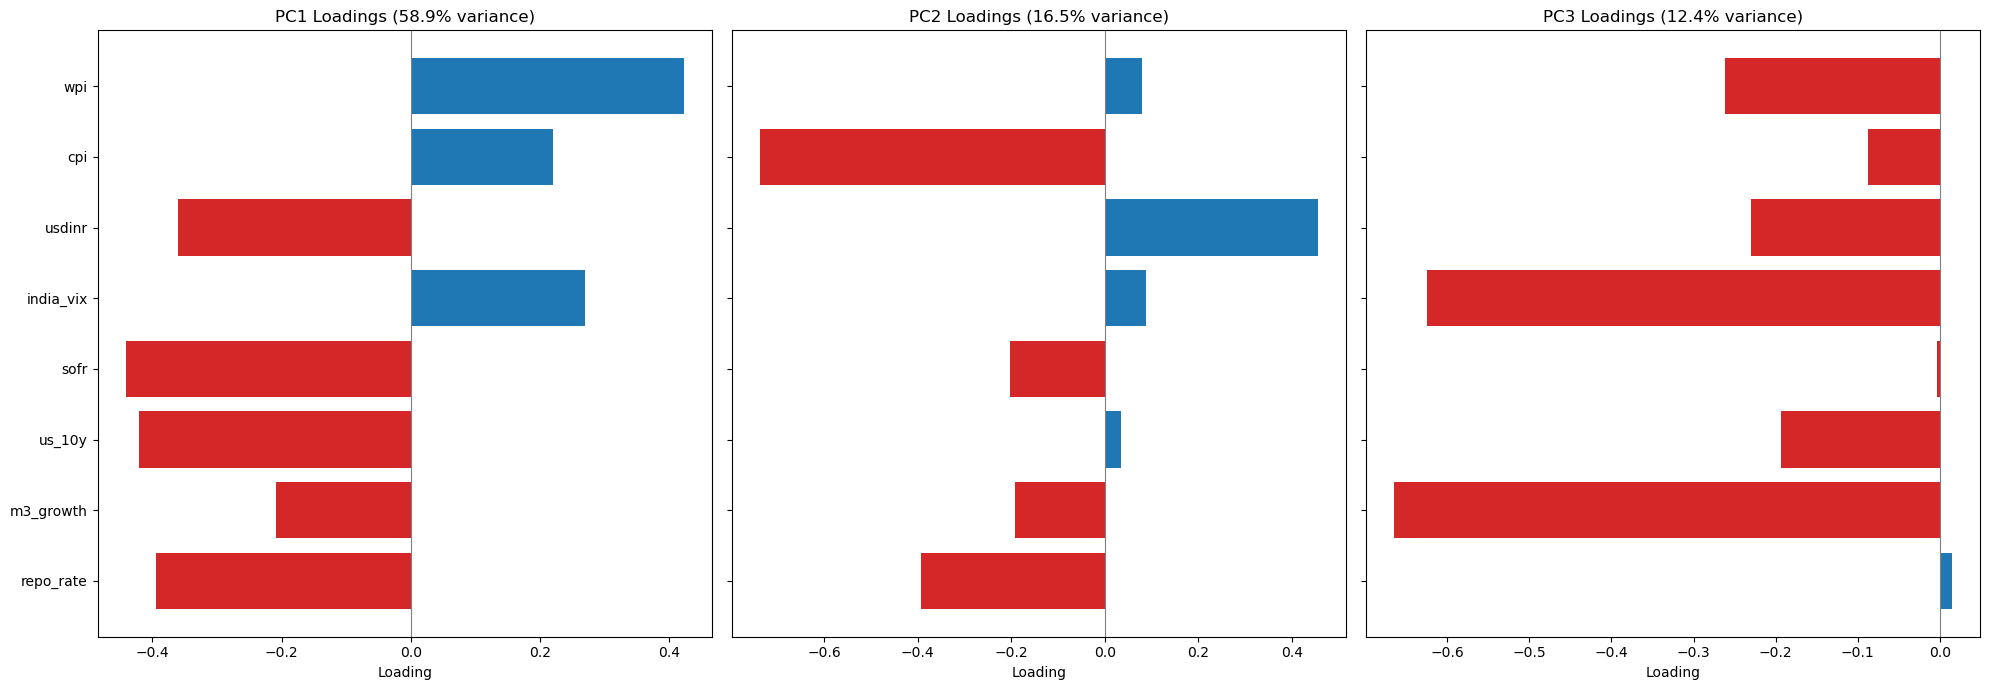

In [77]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    colors = ['tab:blue' if v >= 0 else 'tab:red' for v in loadings[pc]]
    axes[i].barh(loadings.index, loadings[pc], color=colors)
    axes[i].axvline(0, color='gray', linewidth=0.8)
    axes[i].set_title(f'{pc} Loadings ({variance_explained[i]:.1f}% variance)')
    axes[i].set_xlabel('Loading')

plt.tight_layout()
plt.show()

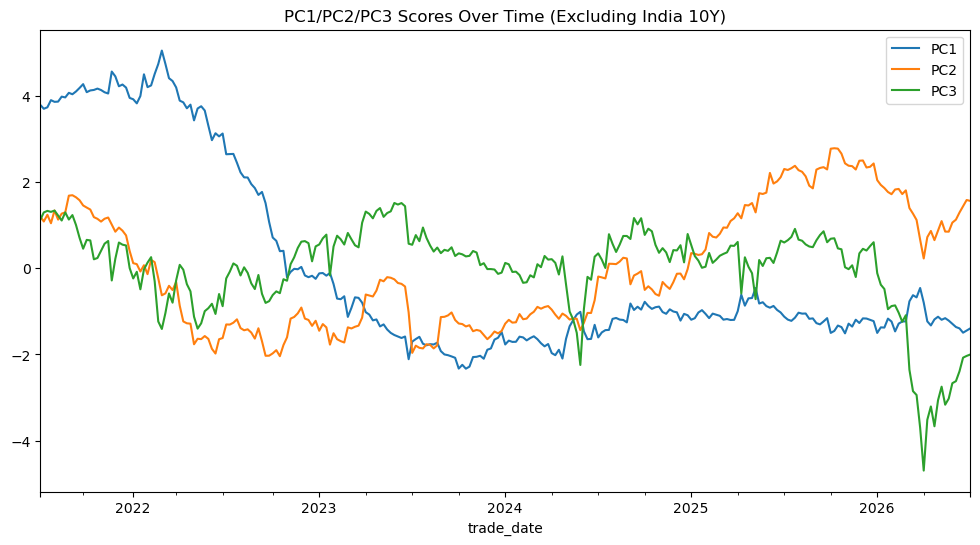

In [78]:
pc_scores.plot(figsize=(12,6), title='PC1/PC2/PC3 Scores Over Time (Excluding India 10Y)')
plt.show()

In [79]:
india_10y_weekly = weekly_matrix['india_10y'].reindex(pc_scores.index)

print("Correlation: India 10Y (weekly) vs each PC score (india_10y excluded from PCA input)")
for col in pc_scores.columns:
    print(f"  {col}: {india_10y_weekly.corr(pc_scores[col]):.4f}")

Correlation: India 10Y (weekly) vs each PC score (india_10y excluded from PCA input)
  PC1: -0.2198
  PC2: -0.8789
  PC3: -0.1796


In [80]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(pc_scores['PC2'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("→ Stationary (good, can use ARIMA with d=0)")
else:
    print("→ Not stationary (will need differencing, d=1)")

ADF Statistic: -1.3014
p-value: 0.6285
→ Not stationary (will need differencing, d=1)


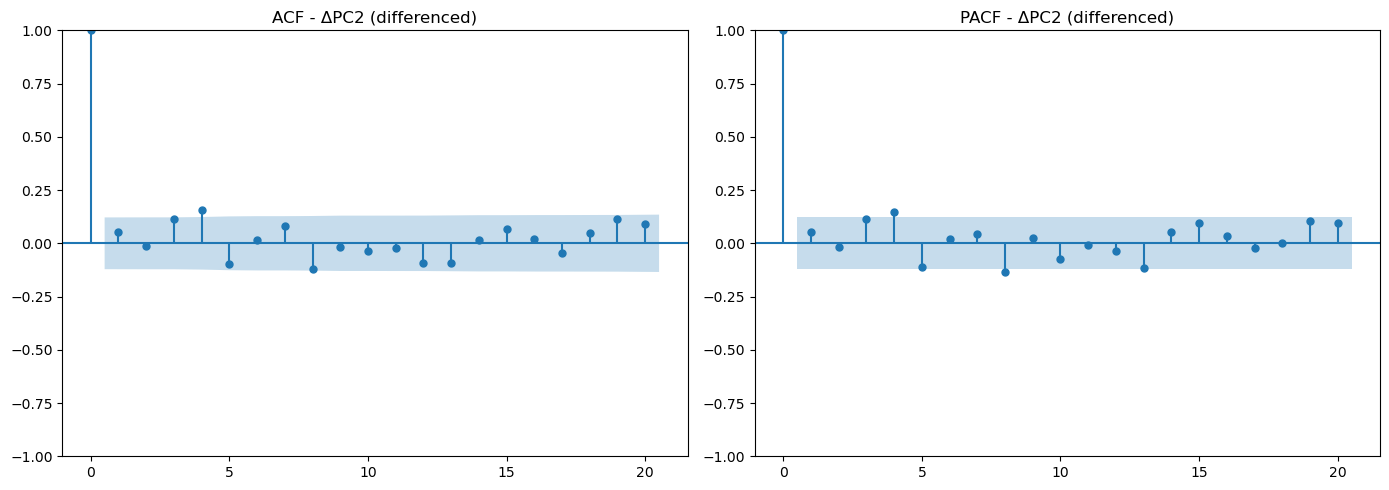

In [81]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

pc2_diff = pc_scores['PC2'].diff().dropna()  # difference once, since d=1

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(pc2_diff, lags=20, ax=axes[0])
plot_pacf(pc2_diff, lags=20, ax=axes[1])
axes[0].set_title('ACF - ΔPC2 (differenced)')
axes[1].set_title('PACF - ΔPC2 (differenced)')
plt.tight_layout()
plt.show()

In [82]:
train_size = int(len(pc_scores) * 0.85)
pc2_train = pc_scores['PC2'].iloc[:train_size]
pc2_test = pc_scores['PC2'].iloc[train_size:]

print(f"Train: {len(pc2_train)} weeks, Test: {len(pc2_test)} weeks")

Train: 221 weeks, Test: 40 weeks


In [83]:
from statsmodels.tsa.arima.model import ARIMA

for order in [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]:
    model = ARIMA(pc2_train, order=order)
    fit = model.fit()
    print(f"Order {order}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")

Order (0, 1, 0): AIC = -81.35, BIC = -77.95
Order (1, 1, 0): AIC = -79.74, BIC = -72.96
Order (0, 1, 1): AIC = -79.74, BIC = -72.95
Order (1, 1, 1): AIC = -78.88, BIC = -68.70


                               SARIMAX Results                                
Dep. Variable:                    PC2   No. Observations:                  221
Model:                 ARIMA(0, 1, 0)   Log Likelihood                  41.673
Date:                Wed, 12 Aug 2026   AIC                            -81.346
Time:                        09:41:43   BIC                            -77.953
Sample:                    07-09-2021   HQIC                           -79.976
                         - 09-26-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0401      0.002     16.463      0.000       0.035       0.045
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                86.24
Prob(Q):                              0.53   Pr

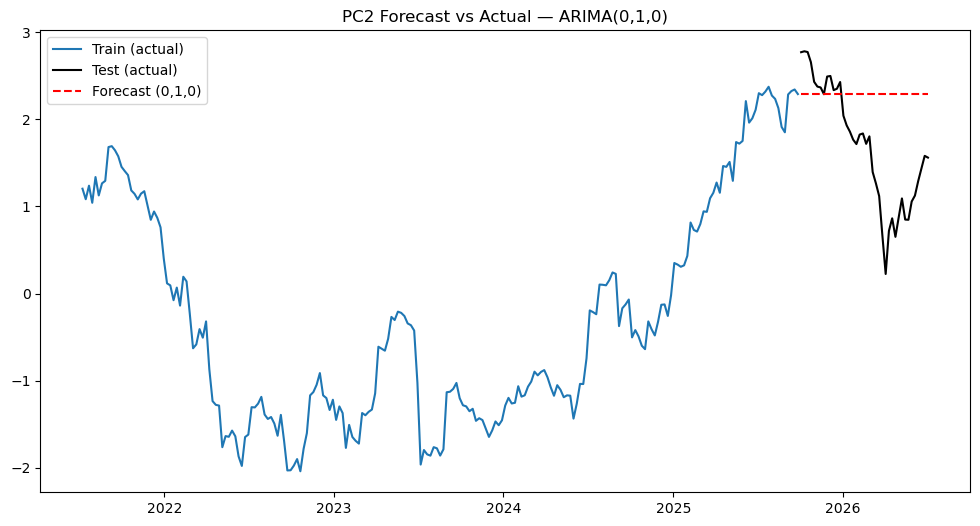

In [84]:
model_pc2 = ARIMA(pc2_train, order=(0,1,0))
fit_pc2 = model_pc2.fit()
print(fit_pc2.summary())

forecast_pc2 = fit_pc2.forecast(steps=len(pc2_test))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(pc2_train.index, pc2_train, label='Train (actual)')
plt.plot(pc2_test.index, pc2_test, label='Test (actual)', color='black')
plt.plot(pc2_test.index, forecast_pc2, label='Forecast (0,1,0)', color='red', linestyle='--')
plt.legend()
plt.title('PC2 Forecast vs Actual — ARIMA(0,1,0)')
plt.show()

In [85]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(pc2_test, forecast_pc2))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.9156


In [86]:
print(f"PC2 test period std dev: {pc2_test.std():.4f}")
print(f"PC2 test period range: {pc2_test.min():.4f} to {pc2_test.max():.4f}")

PC2 test period std dev: 0.7014
PC2 test period range: 0.2245 to 2.7814


RMSE with drift: 1.0194


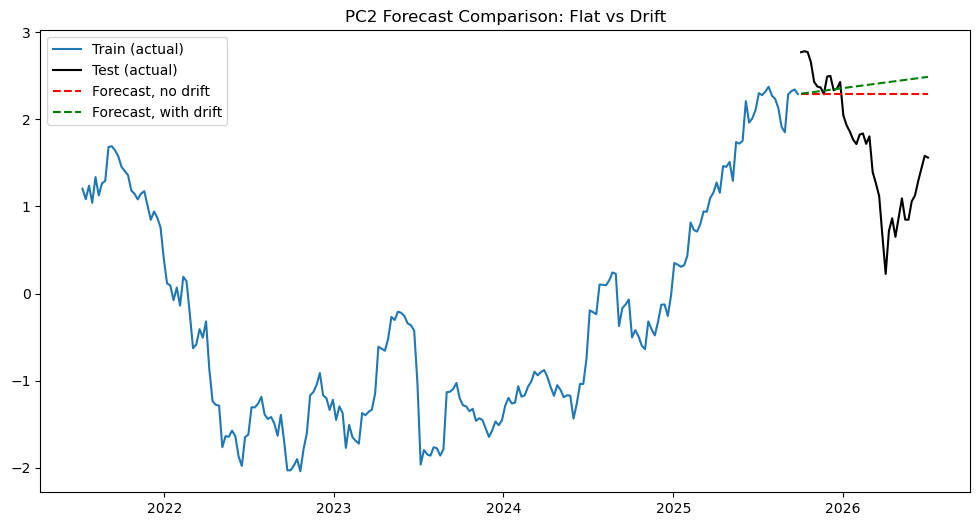

In [87]:
model_pc2_drift = ARIMA(pc2_train, order=(0,1,0), trend='t')
fit_pc2_drift = model_pc2_drift.fit()

forecast_pc2_drift = fit_pc2_drift.forecast(steps=len(pc2_test))

rmse_drift = np.sqrt(mean_squared_error(pc2_test, forecast_pc2_drift))
print(f"RMSE with drift: {rmse_drift:.4f}")

plt.figure(figsize=(12,6))
plt.plot(pc2_train.index, pc2_train, label='Train (actual)')
plt.plot(pc2_test.index, pc2_test, label='Test (actual)', color='black')
plt.plot(pc2_test.index, forecast_pc2, label='Forecast, no drift', color='red', linestyle='--')
plt.plot(pc2_test.index, forecast_pc2_drift, label='Forecast, with drift', color='green', linestyle='--')
plt.legend()
plt.title('PC2 Forecast Comparison: Flat vs Drift')
plt.show()

In [88]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(pc_scores['PC1'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("→ Stationary (good, can use ARIMA with d=0)")
else:
    print("→ Not stationary (will need differencing, d=1)")

ADF Statistic: -1.6658
p-value: 0.4488
→ Not stationary (will need differencing, d=1)


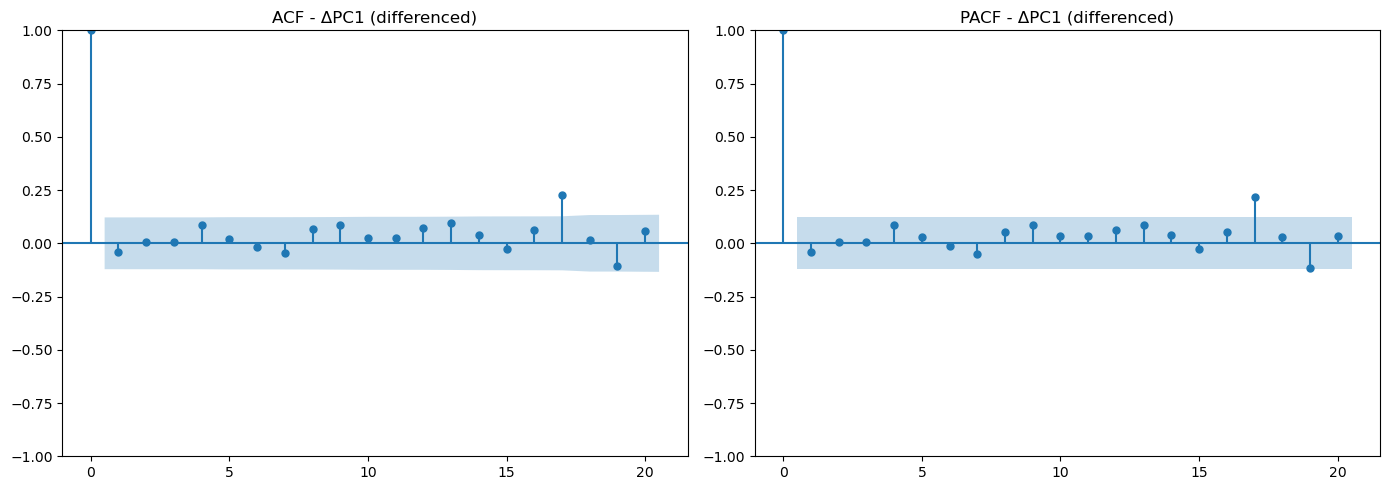

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

pc1_diff = pc_scores['PC1'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(pc1_diff, lags=20, ax=axes[0])
plot_pacf(pc1_diff, lags=20, ax=axes[1])
axes[0].set_title('ACF - ΔPC1 (differenced)')
axes[1].set_title('PACF - ΔPC1 (differenced)')
plt.tight_layout()
plt.show()

In [90]:
train_size = int(len(pc_scores) * 0.85)
pc1_train = pc_scores['PC1'].iloc[:train_size]
pc1_test = pc_scores['PC1'].iloc[train_size:]

print(f"Train: {len(pc1_train)} weeks, Test: {len(pc1_test)} weeks")

Train: 221 weeks, Test: 40 weeks


In [91]:
from statsmodels.tsa.arima.model import ARIMA

for order in [(0,1,0), (1,1,0), (0,1,1), (1,1,1)]:
    model = ARIMA(pc1_train, order=order)
    fit = model.fit()
    print(f"Order {order}: AIC = {fit.aic:.2f}, BIC = {fit.bic:.2f}")

Order (0, 1, 0): AIC = -138.84, BIC = -135.44
Order (1, 1, 0): AIC = -137.04, BIC = -130.25
Order (0, 1, 1): AIC = -137.02, BIC = -130.23
Order (1, 1, 1): AIC = -135.68, BIC = -125.50


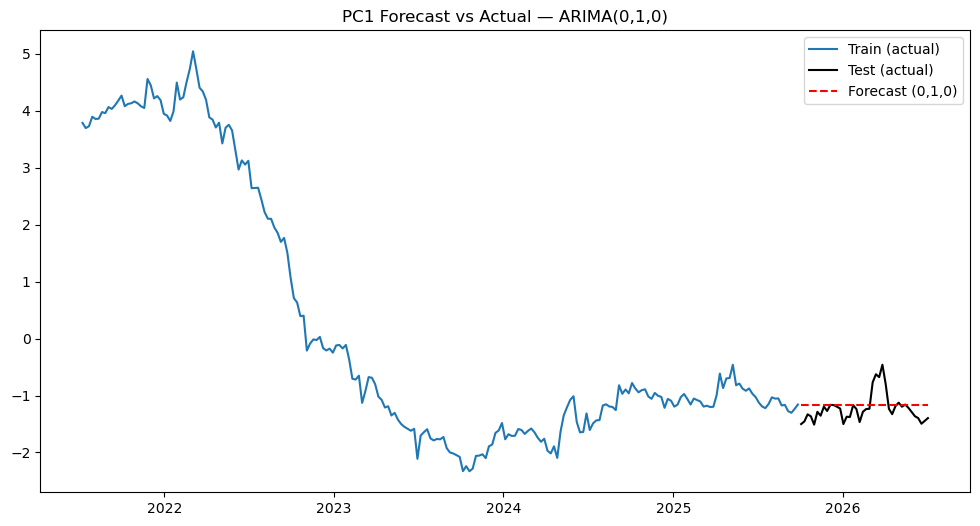

In [92]:
model_pc1 = ARIMA(pc1_train, order=(0,1,0))
fit_pc1 = model_pc1.fit()

forecast_pc1 = fit_pc1.forecast(steps=len(pc1_test))

plt.figure(figsize=(12,6))
plt.plot(pc1_train.index, pc1_train, label='Train (actual)')
plt.plot(pc1_test.index, pc1_test, label='Test (actual)', color='black')
plt.plot(pc1_test.index, forecast_pc1, label='Forecast (0,1,0)', color='red', linestyle='--')
plt.legend()
plt.title('PC1 Forecast vs Actual — ARIMA(0,1,0)')
plt.show()

In [93]:
rmse_pc1 = np.sqrt(mean_squared_error(pc1_test, forecast_pc1))
print(f"RMSE: {rmse_pc1:.4f}")

print(f"PC1 test period std dev: {pc1_test.std():.4f}")
print(f"PC1 test period range: {pc1_test.min():.4f} to {pc1_test.max():.4f}")

RMSE: 0.2506
PC1 test period std dev: 0.2443
PC1 test period range: -1.5115 to -0.4594


In [94]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas as pd

def rolling_backtest(series, window=150, horizon=4, step=4, order=(0,1,0)):
    """
    window: how many weeks of history to train on each time
    horizon: how many weeks ahead to forecast each time
    step: how many weeks to move forward between each test
    """
    errors = []
    dates = []
    for start in range(0, len(series) - window - horizon, step):
        train = series.iloc[start : start + window]
        test = series.iloc[start + window : start + window + horizon]
        if len(test) < horizon:
            continue
        try:
            fit = ARIMA(train, order=order).fit()
            forecast = fit.forecast(steps=horizon)
            rmse = np.sqrt(mean_squared_error(test, forecast))
            errors.append(rmse)
            dates.append(test.index[0])
        except Exception:
            continue
    return pd.Series(errors, index=dates)

In [95]:
import pandas as pd

pc1_rolling_rmse = rolling_backtest(pc_scores['PC1'], window=150, horizon=4, step=4)
pc2_rolling_rmse = rolling_backtest(pc_scores['PC2'], window=150, horizon=4, step=4)

print("PC1 rolling backtest:")
print(f"  Mean RMSE: {pc1_rolling_rmse.mean():.4f}")
print(f"  Std of RMSE across windows: {pc1_rolling_rmse.std():.4f}")
print(f"  Number of windows tested: {len(pc1_rolling_rmse)}")

print("\nPC2 rolling backtest:")
print(f"  Mean RMSE: {pc2_rolling_rmse.mean():.4f}")
print(f"  Std of RMSE across windows: {pc2_rolling_rmse.std():.4f}")
print(f"  Number of windows tested: {len(pc2_rolling_rmse)}")

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Aditi Raj\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


PC1 rolling backtest:
  Mean RMSE: 0.1836
  Std of RMSE across windows: 0.1035
  Number of windows tested: 27

PC2 rolling backtest:
  Mean RMSE: 0.2549
  Std of RMSE across windows: 0.1436
  Number of windows tested: 27


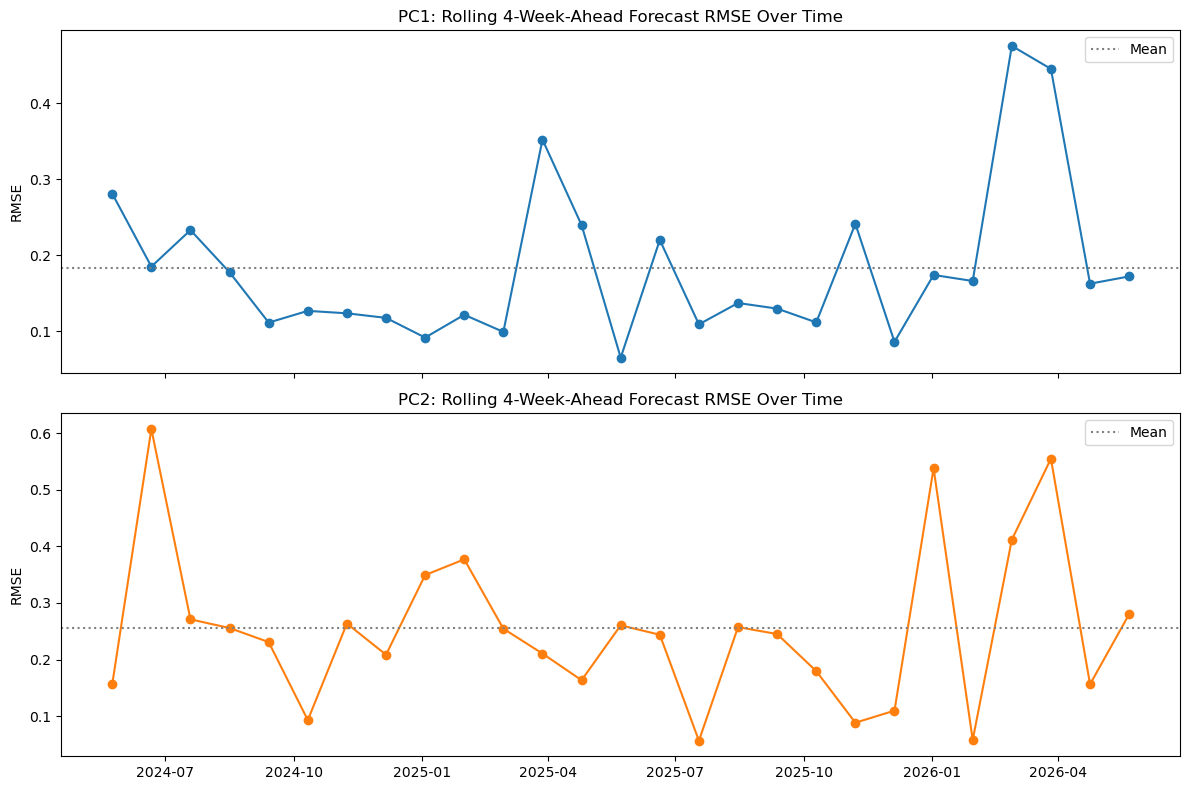

In [96]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

axes[0].plot(pc1_rolling_rmse.index, pc1_rolling_rmse, marker='o', color='tab:blue')
axes[0].axhline(pc1_rolling_rmse.mean(), color='gray', linestyle=':', label='Mean')
axes[0].set_title('PC1: Rolling 4-Week-Ahead Forecast RMSE Over Time')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(pc2_rolling_rmse.index, pc2_rolling_rmse, marker='o', color='tab:orange')
axes[1].axhline(pc2_rolling_rmse.mean(), color='gray', linestyle=':', label='Mean')
axes[1].set_title('PC2: Rolling 4-Week-Ahead Forecast RMSE Over Time')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [97]:
import statsmodels.api as sm

X = pc_scores[['PC2']]
X = sm.add_constant(X)
y = weekly_matrix['india_10y'].reindex(pc_scores.index)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     879.1
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           3.14e-85
Time:                        09:41:48   Log-Likelihood:                 86.058
No. Observations:                 261   AIC:                            -168.1
Df Residuals:                     259   BIC:                            -161.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8922      0.011    637.442      0.0

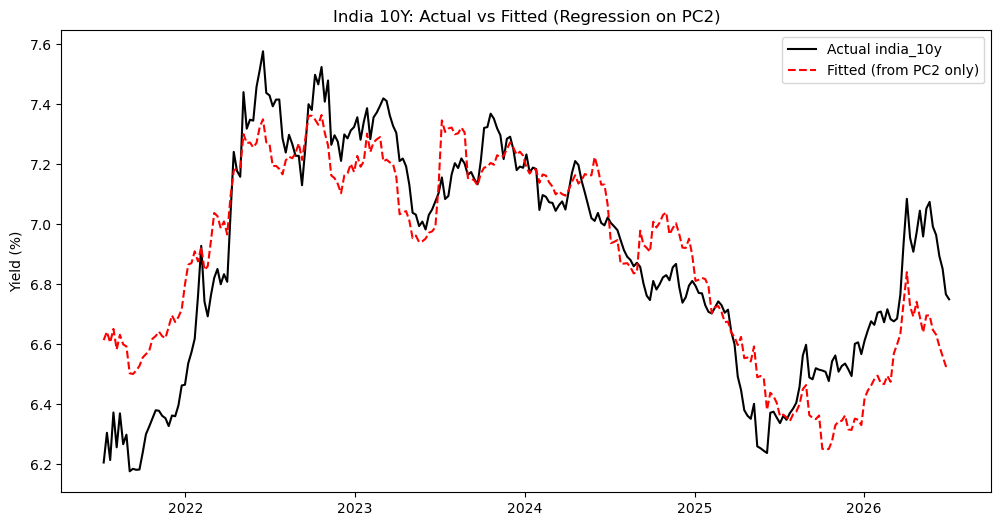

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y.index, y, label='Actual india_10y', color='black')
plt.plot(y.index, model.fittedvalues, label='Fitted (from PC2 only)', color='red', linestyle='--')
plt.legend()
plt.title('India 10Y: Actual vs Fitted (Regression on PC2)')
plt.ylabel('Yield (%)')
plt.show()

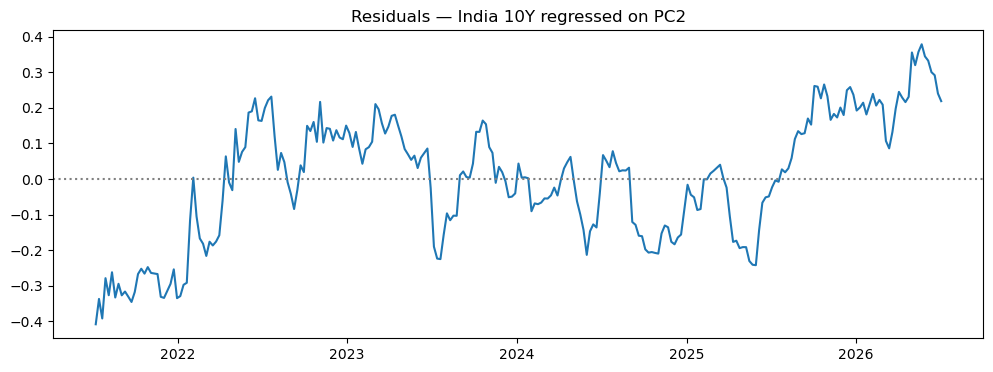

In [99]:
residuals = model.resid

plt.figure(figsize=(12,4))
plt.plot(residuals.index, residuals)
plt.axhline(0, color='gray', linestyle=':')
plt.title('Residuals — India 10Y regressed on PC2')
plt.show()

In [100]:
import statsmodels.api as sm

X_pc1 = pc_scores[['PC1']]
X_pc1 = sm.add_constant(X_pc1)
y = weekly_matrix['india_10y'].reindex(pc_scores.index)

model_pc1 = sm.OLS(y, X_pc1).fit()
print(model_pc1.summary())

                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     13.15
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           0.000346
Time:                        09:41:48   Log-Likelihood:                -100.66
No. Observations:                 261   AIC:                             205.3
Df Residuals:                     259   BIC:                             212.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.8922      0.022    311.710      0.0

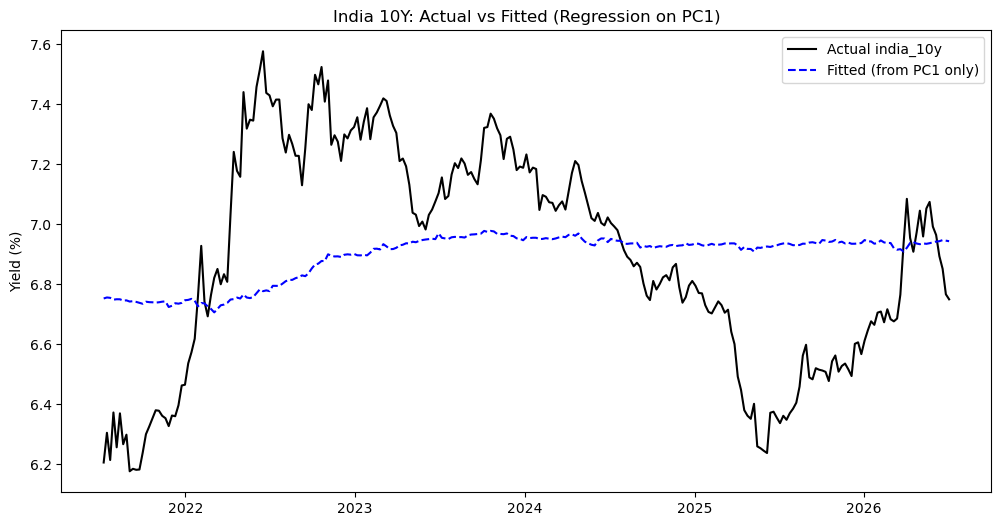

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y.index, y, label='Actual india_10y', color='black')
plt.plot(y.index, model_pc1.fittedvalues, label='Fitted (from PC1 only)', color='blue', linestyle='--')
plt.legend()
plt.title('India 10Y: Actual vs Fitted (Regression on PC1)')
plt.ylabel('Yield (%)')
plt.show()

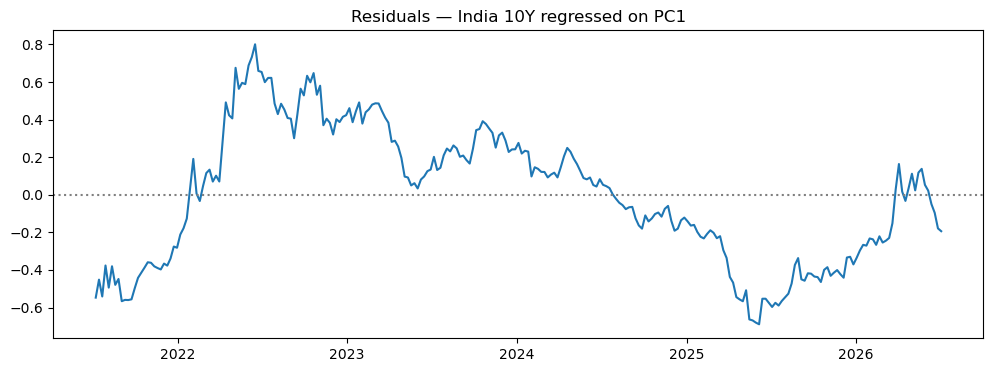

In [102]:
residuals_pc1 = model_pc1.resid

plt.figure(figsize=(12,4))
plt.plot(residuals_pc1.index, residuals_pc1)
plt.axhline(0, color='gray', linestyle=':')
plt.title('Residuals — India 10Y regressed on PC1')
plt.show()

In [103]:
import statsmodels.api as sm
import pandas as pd

y = weekly_matrix['india_10y']

variables_to_test = ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']

results = []

for var in variables_to_test:
    X = weekly_matrix[[var]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    results.append({
        'Variable': var,
        'R_squared': model.rsquared,
        'Coefficient': model.params[var],
        'p_value': model.pvalues[var],
        'Durbin_Watson': sm.stats.stattools.durbin_watson(model.resid)
    })
    
    print(f"\n{'='*60}")
    print(f"Regression: india_10y ~ {var}")
    print(f"{'='*60}")
    print(model.summary())

summary_table = pd.DataFrame(results).sort_values('R_squared', ascending=False)
print("\n\nSUMMARY TABLE (sorted by R²):")
print(summary_table.to_string(index=False))


Regression: india_10y ~ repo_rate
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     62.71
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           7.05e-14
Time:                        09:41:49   Log-Likelihood:                -78.825
No. Observations:                 261   AIC:                             161.7
Df Residuals:                     259   BIC:                             168.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.

In [104]:
def backward_elimination(X, y, threshold=0.05):
    X = X.copy()
    while True:
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        pvalues = model.pvalues.drop('const')
        max_p = pvalues.max()
        if max_p > threshold:
            worst_feature = pvalues.idxmax()
            print(f"Removing '{worst_feature}' (p={max_p:.4f})")
            X = X.drop(columns=[worst_feature])
        else:
            break
    return X, model

predictors_raw = weekly_matrix[['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']]
y = weekly_matrix['india_10y']

final_vars_backward, final_model_backward = backward_elimination(predictors_raw, y)
print("\nFinal variables (backward):", list(final_vars_backward.columns))
print(final_model_backward.summary())

Removing 'repo_rate' (p=0.2632)
Removing 'us_10y' (p=0.1871)
Removing 'm3_growth' (p=0.1410)

Final variables (backward): ['sofr', 'usdinr', 'cpi', 'wpi']
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     152.5
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           1.59e-66
Time:                        09:41:49   Log-Likelihood:                 51.942
No. Observations:                 261   AIC:                            -93.88
Df Residuals:                     256   BIC:                            -76.06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t| 

In [105]:
import statsmodels.api as sm
import pandas as pd

y = weekly_matrix['india_10y']
variables_to_test = ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']

univariate_results = []
for var in variables_to_test:
    X = sm.add_constant(weekly_matrix[[var]])
    model = sm.OLS(y, X).fit()
    univariate_results.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table = pd.DataFrame(univariate_results).sort_values('R_squared', ascending=False)
print(univariate_table.to_string(index=False))

 Variable  R_squared      p_value
      cpi   0.294322 2.244411e-21
repo_rate   0.194937 7.051302e-14
m3_growth   0.116508 1.524423e-08
     sofr   0.099254 2.011575e-07
   us_10y   0.084635 1.742242e-06
      wpi   0.000257 7.965584e-01
   usdinr   0.000096 8.748281e-01


In [106]:
# order variables by their individual R² (strongest first), based on step 1's table
ladder_order = univariate_table['Variable'].tolist()

selected_vars = []
for var in ladder_order:
    selected_vars.append(var)
    X_step = sm.add_constant(weekly_matrix[selected_vars])
    model_step = sm.OLS(y, X_step).fit()
    
    print(f"\n{'='*70}")
    print(f"STEP {len(selected_vars)}: india_10y ~ {' + '.join(selected_vars)}")
    print(f"{'='*70}")
    print(f"R-squared: {model_step.rsquared:.4f}")
    print(f"\np-values:")
    print(model_step.pvalues.drop('const').to_string())
    print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(model_step.resid):.4f}")


STEP 1: india_10y ~ cpi
R-squared: 0.2943

p-values:
cpi    2.244411e-21

Durbin-Watson: 0.0522

STEP 2: india_10y ~ cpi + repo_rate
R-squared: 0.4954

p-values:
cpi          5.406395e-28
repo_rate    1.485860e-20

Durbin-Watson: 0.0729

STEP 3: india_10y ~ cpi + repo_rate + m3_growth
R-squared: 0.5426

p-values:
cpi          1.100264e-30
repo_rate    2.984832e-14
m3_growth    5.212802e-07

Durbin-Watson: 0.0956

STEP 4: india_10y ~ cpi + repo_rate + m3_growth + sofr
R-squared: 0.5489

p-values:
cpi          4.140560e-17
repo_rate    7.482424e-01
m3_growth    1.351081e-04
sofr         5.904733e-02

Durbin-Watson: 0.1004

STEP 5: india_10y ~ cpi + repo_rate + m3_growth + sofr + us_10y
R-squared: 0.6306

p-values:
cpi          8.363995e-25
repo_rate    7.046035e-01
m3_growth    1.504349e-04
sofr         8.407079e-01
us_10y       1.010112e-12

Durbin-Watson: 0.1240

STEP 6: india_10y ~ cpi + repo_rate + m3_growth + sofr + us_10y + wpi
R-squared: 0.6951

p-values:
cpi          1.231618e-1

In [107]:
threshold = 0.05
final_step_pvalues = model_step.pvalues.drop('const')

print("Final step significance check (p < 0.05 = significant):")
for var, p in final_step_pvalues.items():
    status = "✓ SIGNIFICANT" if p < threshold else "✗ not significant"
    print(f"  {var:12s} p={p:.6f}  {status}")

Final step significance check (p < 0.05 = significant):
  cpi          p=0.000000  ✓ SIGNIFICANT
  repo_rate    p=0.263244  ✗ not significant
  m3_growth    p=0.240266  ✗ not significant
  sofr         p=0.000398  ✓ SIGNIFICANT
  us_10y       p=0.207124  ✗ not significant
  wpi          p=0.000000  ✓ SIGNIFICANT
  usdinr       p=0.000309  ✓ SIGNIFICANT


In [108]:
import pandas as pd

# ------------------------------------------------------------------
# Track how each variable's significance evolves across the ladder
# ------------------------------------------------------------------
ladder_history = []

selected_vars = []
for step_num, var in enumerate(ladder_order, start=1):
    selected_vars.append(var)
    X_step = sm.add_constant(weekly_matrix[selected_vars])
    model_step = sm.OLS(y, X_step).fit()
    
    for v in selected_vars:
        ladder_history.append({
            'Step': step_num,
            'Variables_in_model': ' + '.join(selected_vars),
            'Variable': v,
            'p_value': model_step.pvalues[v],
            'Significant': model_step.pvalues[v] < 0.05
        })

ladder_df = pd.DataFrame(ladder_history)

# ------------------------------------------------------------------
# Pivot: rows = variable, columns = step, values = significant or not
# ------------------------------------------------------------------
significance_matrix = ladder_df.pivot(index='Variable', columns='Step', values='Significant')
significance_matrix = significance_matrix.reindex(ladder_order)  # keep entry order

print("Significance across the ladder (True = p < 0.05):\n")
print(significance_matrix.fillna('-').to_string())

# ------------------------------------------------------------------
# Final step significance check
# ------------------------------------------------------------------
final_step = ladder_df['Step'].max()
final_pvals = ladder_df[ladder_df['Step'] == final_step].set_index('Variable')['p_value']

print(f"\n\nFinal model (all {final_step} variables) significance check:")
for var, p in final_pvals.items():
    status = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
    print(f"  {var:12s} p={p:.6f}  {status}")

# ------------------------------------------------------------------
# Flag which variables lost significance somewhere along the ladder
# ------------------------------------------------------------------
print("\n\nVariables that LOST significance at some point in the ladder:")
for var in ladder_order:
    row = significance_matrix.loc[var].dropna()
    if row.iloc[0] == True and False in row.values:
        drop_step = row[row == False].index[0]
        print(f"  {var}: significant at step {row.index[0]}, dropped to non-significant by step {drop_step}")

print("\nVariables that stayed significant throughout:")
for var in ladder_order:
    row = significance_matrix.loc[var].dropna()
    if all(row == True):
        print(f"  {var}: significant at every step it appeared in")

Significance across the ladder (True = p < 0.05):

Step          1     2     3      4      5      6      7
Variable                                               
cpi        True  True  True   True   True   True   True
repo_rate     -  True  True  False  False  False  False
m3_growth     -     -  True   True   True  False  False
sofr          -     -     -  False  False   True   True
us_10y        -     -     -      -   True   True  False
wpi           -     -     -      -      -   True   True
usdinr        -     -     -      -      -      -   True


Final model (all 7 variables) significance check:
  cpi          p=0.000000  ✓ SIGNIFICANT
  repo_rate    p=0.263244  ✗ not significant
  m3_growth    p=0.240266  ✗ not significant
  sofr         p=0.000398  ✓ SIGNIFICANT
  us_10y       p=0.207124  ✗ not significant
  wpi          p=0.000000  ✓ SIGNIFICANT
  usdinr       p=0.000309  ✓ SIGNIFICANT


Variables that LOST significance at some point in the ladder:
  repo_rate: significant at st

C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_20808\1867351020.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(significance_matrix.fillna('-').to_string())


In [109]:
import statsmodels.api as sm
import pandas as pd

significant_vars = ['sofr', 'usdinr', 'cpi', 'wpi']

X_lagged = weekly_matrix[significant_vars].shift(1).dropna()
y_aligned = weekly_matrix['india_10y'].reindex(X_lagged.index)

X_lagged_const = sm.add_constant(X_lagged)
model_lagged = sm.OLS(y_aligned, X_lagged_const).fit()
print(model_lagged.summary())

                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     139.4
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           5.82e-63
Time:                        09:41:49   Log-Likelihood:                 45.256
No. Observations:                 260   AIC:                            -80.51
Df Residuals:                     255   BIC:                            -62.71
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5821      0.491      5.263      0.0

In [110]:
last_known_values = weekly_matrix[significant_vars].iloc[[-1]]  # most recent actual week
X_next = sm.add_constant(last_known_values, has_constant='add')

next_week_forecast = model_lagged.predict(X_next)
next_week_date = weekly_matrix.index[-1] + pd.Timedelta(weeks=1)

print(f"\nForecast for {next_week_date.date()}: india_10y ≈ {next_week_forecast.values[0]:.4f}")


Forecast for 2026-07-10: india_10y ≈ 6.9344


In [111]:
window = 150
horizon = 1
errors = []
predictions = []
actuals = []
dates = []

X_all = weekly_matrix[significant_vars].shift(1).dropna()
y_all = weekly_matrix['india_10y'].reindex(X_all.index)

for start in range(0, len(X_all) - window - horizon):
    X_train = sm.add_constant(X_all.iloc[start:start+window])
    y_train = y_all.iloc[start:start+window]
    X_test = sm.add_constant(X_all.iloc[[start+window]], has_constant='add')
    y_test = y_all.iloc[start+window]
    
    m = sm.OLS(y_train, X_train).fit()
    pred = m.predict(X_test).values[0]
    
    predictions.append(pred)
    actuals.append(y_test)
    dates.append(y_all.index[start+window])

import numpy as np
from sklearn.metrics import mean_squared_error

rmse_lagged = np.sqrt(mean_squared_error(actuals, predictions))
print(f"\nWalk-forward RMSE (1-week-ahead lagged regression): {rmse_lagged:.4f}")


Walk-forward RMSE (1-week-ahead lagged regression): 0.2822


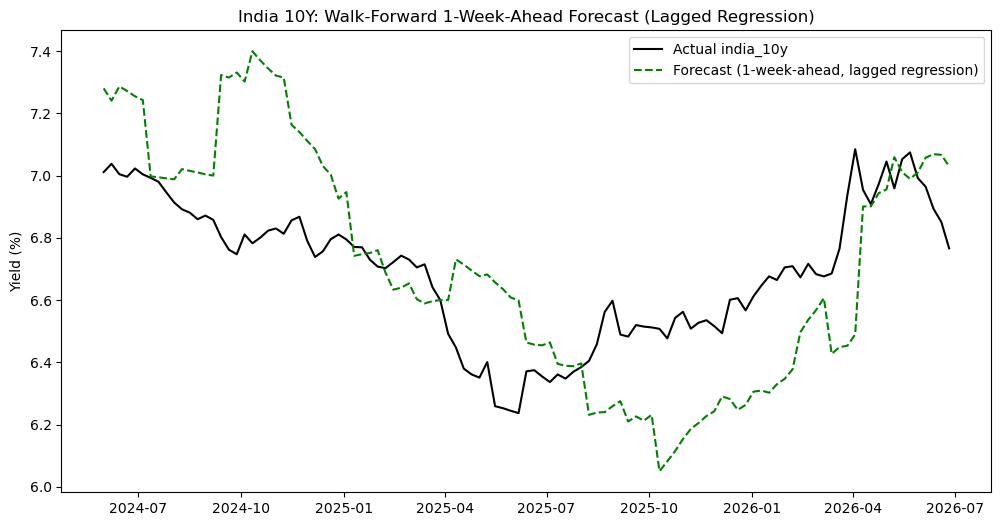

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(dates, actuals, label='Actual india_10y', color='black')
plt.plot(dates, predictions, label='Forecast (1-week-ahead, lagged regression)', color='green', linestyle='--')
plt.legend()
plt.title('India 10Y: Walk-Forward 1-Week-Ahead Forecast (Lagged Regression)')
plt.ylabel('Yield (%)')
plt.show()

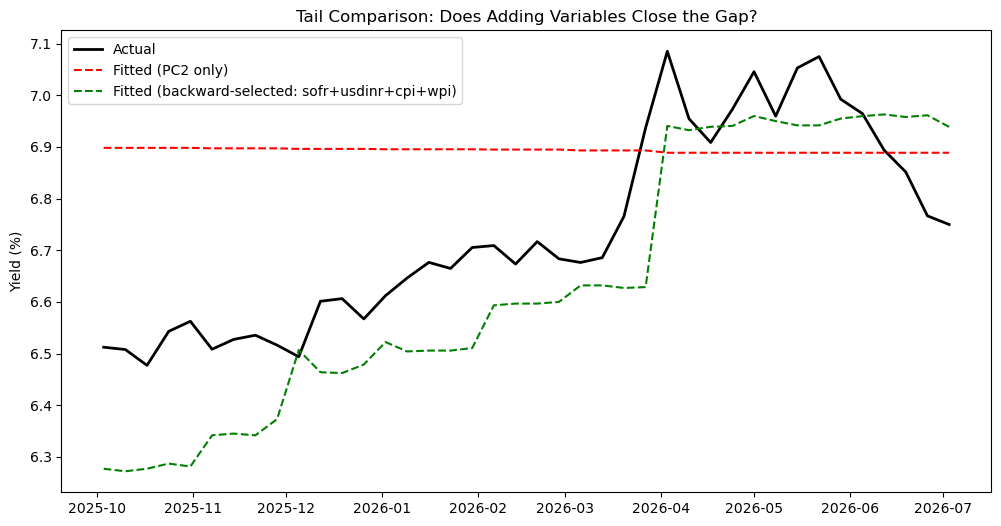

In [113]:
plt.figure(figsize=(12,6))
plt.plot(weekly_matrix.index[-40:], weekly_matrix['india_10y'].iloc[-40:], label='Actual', color='black', linewidth=2)
plt.plot(weekly_matrix.index[-40:], model.fittedvalues.iloc[-40:], label='Fitted (PC2 only)', color='red', linestyle='--')
plt.plot(final_vars_backward.index[-40:], final_model_backward.fittedvalues.iloc[-40:], label='Fitted (backward-selected: sofr+usdinr+cpi+wpi)', color='green', linestyle='--')
plt.legend()
plt.title('Tail Comparison: Does Adding Variables Close the Gap?')
plt.ylabel('Yield (%)')
plt.show()

**Finding: Adding sofr, usdinr, cpi, and wpi (from backward elimination) substantially
improved tracking versus PC2 alone.** The PC2-only model stayed flat and missed the
entire 2025–2026 rally, while the multi-variable model followed the trend and reacted
to the April 2026 spike, even though it still lagged the exact peak. This confirms
that PC2 alone was leaving real, recoverable signal on the table.

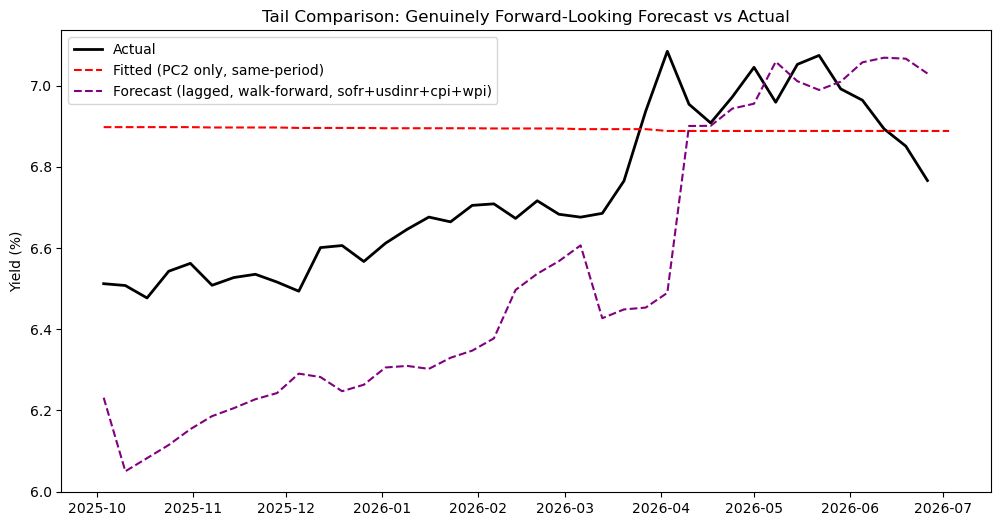

In [114]:
import matplotlib.pyplot as plt
import pandas as pd

# convert the walk-forward results into a proper indexed Series for easy slicing
walkforward_series = pd.Series(predictions, index=dates)
actuals_series = pd.Series(actuals, index=dates)

# zoom into the same tail window as before
tail_start = '2025-10-01'

plt.figure(figsize=(12,6))
plt.plot(actuals_series[tail_start:].index, actuals_series[tail_start:], 
         label='Actual', color='black', linewidth=2)
plt.plot(y.index[y.index >= tail_start], model.fittedvalues[y.index >= tail_start], 
         label='Fitted (PC2 only, same-period)', color='red', linestyle='--')
plt.plot(walkforward_series[tail_start:].index, walkforward_series[tail_start:], 
         label='Forecast (lagged, walk-forward, sofr+usdinr+cpi+wpi)', color='purple', linestyle='--')
plt.legend()
plt.title('Tail Comparison: Genuinely Forward-Looking Forecast vs Actual')
plt.ylabel('Yield (%)')
plt.show()

In [115]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

significant_vars = ['sofr', 'usdinr', 'cpi', 'wpi']
window = 150

horizons_to_test = [1, 4, 8]  # weeks ahead
results_by_horizon = {}

for horizon in horizons_to_test:
    X_all = weekly_matrix[significant_vars].shift(horizon).dropna()
    y_all = weekly_matrix['india_10y'].reindex(X_all.index)
    
    predictions = []
    actuals = []
    dates = []
    
    for start in range(0, len(X_all) - window - 1):
        X_train = sm.add_constant(X_all.iloc[start:start+window])
        y_train = y_all.iloc[start:start+window]
        X_test = sm.add_constant(X_all.iloc[[start+window]], has_constant='add')
        y_test = y_all.iloc[start+window]
        
        m = sm.OLS(y_train, X_train).fit()
        pred = m.predict(X_test).values[0]
        
        predictions.append(pred)
        actuals.append(y_test)
        dates.append(y_all.index[start+window])
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    results_by_horizon[horizon] = {
        'rmse': rmse,
        'predictions': pd.Series(predictions, index=dates),
        'actuals': pd.Series(actuals, index=dates)
    }
    print(f"{horizon}-week-ahead: RMSE = {rmse:.4f}")

1-week-ahead: RMSE = 0.2822
4-week-ahead: RMSE = 0.2858
8-week-ahead: RMSE = 0.3097


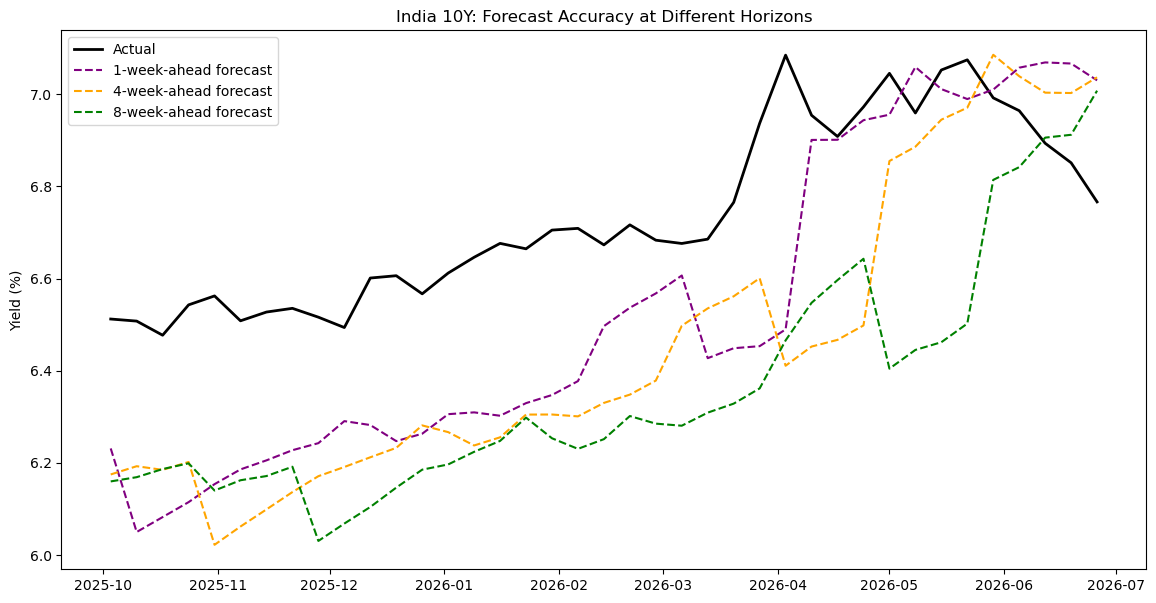

In [116]:
import matplotlib.pyplot as plt

tail_start = '2025-10-01'

plt.figure(figsize=(14,7))
plt.plot(results_by_horizon[1]['actuals'][tail_start:].index, 
         results_by_horizon[1]['actuals'][tail_start:], 
         label='Actual', color='black', linewidth=2)

colors = {1: 'purple', 4: 'orange', 8: 'green'}
for horizon in horizons_to_test:
    series = results_by_horizon[horizon]['predictions']
    plt.plot(series[tail_start:].index, series[tail_start:], 
              label=f'{horizon}-week-ahead forecast', color=colors[horizon], linestyle='--')

plt.legend()
plt.title('India 10Y: Forecast Accuracy at Different Horizons')
plt.ylabel('Yield (%)')
plt.show()

In [117]:
rmse_table = pd.DataFrame({
    'Horizon (weeks)': horizons_to_test,
    'RMSE': [results_by_horizon[h]['rmse'] for h in horizons_to_test]
})
print(rmse_table.to_string(index=False))

 Horizon (weeks)     RMSE
               1 0.282203
               4 0.285814
               8 0.309686


**Finding: Forecast accuracy degrades with horizon.** RMSE increases from 0.2822 
(1-week-ahead) to 0.2858 (4-week-ahead) to 0.3097 (8-week-ahead). The chart shows 
this directly — shorter-horizon forecasts react to actual yield movements sooner, 
while the 8-week-ahead forecast lags visibly furthest behind at turning points 
(most clearly at the April 2026 spike). This is expected: longer horizons carry 
more accumulated uncertainty, since the model relies on increasingly stale 
information the further out it predicts.

In [118]:
print(weekly_matrix['cpi'].tail(30))

trade_date
2025-12-12    1.33
2025-12-19    1.33
2025-12-26    1.33
2026-01-02    1.33
2026-01-09    1.33
2026-01-16    1.33
2026-01-23    1.33
2026-01-30    1.33
2026-02-06    1.33
2026-02-13    1.33
2026-02-20    1.33
2026-02-27    1.33
2026-03-06    1.33
2026-03-13    1.33
2026-03-20    1.33
2026-03-27    1.33
2026-04-03    1.33
2026-04-10    1.33
2026-04-17    1.33
2026-04-24    1.33
2026-05-01    1.33
2026-05-08    1.33
2026-05-15    1.33
2026-05-22    1.33
2026-05-29    1.33
2026-06-05    1.33
2026-06-12    1.33
2026-06-19    1.33
2026-06-26    1.33
2026-07-03    1.33
Freq: W-FRI, Name: cpi, dtype: float64


In [119]:
def load_cpi_new(path, target_index=None):
    raw = pd.read_csv(path)
    raw = raw[(raw['state'] == 'All India') & (raw['sector'] == 'Combined')].copy()
    raw = raw[['year', 'month_code', 'inflation']].copy()
    raw['date'] = pd.to_datetime(raw['year'].astype(str) + '-' + raw['month_code'].astype(str) + '-01')
    raw = raw.dropna(subset=['inflation']).sort_values('date')
    return raw.set_index('date')['inflation']

# old series (base 2012), new series (base 2024) — both give YoY inflation %, splice them
cpi_old = load_cpi('data/viz_data (1).csv')  # your original loader
cpi_new = load_cpi_new('data/viz_data (2).csv')

# combine: use old series up through Dec 2025, new series for Jan 2026 onward
cpi_combined = pd.concat([
    cpi_old[cpi_old.index < '2026-01-01'],
    cpi_new[cpi_new.index >= '2026-01-01']
]).sort_index()

print(cpi_combined.tail(10))

date
2025-09-01    1.44
2025-10-01    0.25
2025-11-01    0.71
2025-12-01    1.33
2026-01-01    2.74
2026-02-01    3.21
2026-03-01    3.40
2026-04-01    3.48
2026-05-01    3.93
2026-06-01    4.38
dtype: float64


In [120]:
cpi_level = cpi_combined
full_range = pd.date_range(start=cpi_level.index.min(), end=india_10y.index.max(), freq='D')
cpi_daily = cpi_level.reindex(full_range).ffill().reindex(india_10y.index)
cpi_daily.name = 'cpi'

In [121]:
final_matrix = india_10y.to_frame('india_10y').join([
    repo_daily, m3_daily, us10y_daily, sofr_daily,
    india_vix_daily, usdinr_daily, cpi_daily, wpi_daily,
])

weekly_matrix = final_matrix.resample('W-FRI').last().dropna()
print(weekly_matrix.tail(10))

            india_10y  repo_rate  m3_growth  us_10y  sofr  india_vix   usdinr  \
trade_date                                                                      
2026-05-01   7.045475       5.25  12.698547    4.40  3.66      18.46  95.2417   
2026-05-08   6.959434       5.25  12.698547    4.38  3.60      16.84  95.2417   
2026-05-15   7.052718       5.25  12.698547    4.59  3.55      18.79  95.2417   
2026-05-22   7.074777       5.25  12.698547    4.56  3.55      17.91  95.2417   
2026-05-29   6.992232       5.25  12.698547    4.45  3.63      16.19  95.2417   
2026-06-05   6.964413       5.25  12.698547    4.55  3.63      15.79  95.3845   
2026-06-12   6.893714       5.25  12.698547    4.48  3.65      14.72  95.3845   
2026-06-19   6.851337       5.25  12.698547    4.46  3.62      12.97  95.3845   
2026-06-26   6.766475       5.25  12.698547    4.40  3.64      13.05  95.3845   
2026-07-03   6.749750       5.25  12.698547    4.44  3.66      13.24  94.5975   

             cpi       wpi 

In [122]:
cutoff_date = '2025-12-31'

final_matrix_trimmed = final_matrix[final_matrix.index <= cutoff_date]
weekly_matrix_trimmed = final_matrix_trimmed.resample('W-FRI').last().dropna()

print(f"Trimmed weekly panel shape: {weekly_matrix_trimmed.shape}")
print(weekly_matrix_trimmed.tail())

Trimmed weekly panel shape: (235, 9)
            india_10y  repo_rate  m3_growth  us_10y  sofr  india_vix   usdinr  \
trade_date                                                                      
2025-12-05   6.493787       5.25   9.217314    4.14  3.93      10.32  89.4557   
2025-12-12   6.601226       5.25   9.217314    4.19  3.67      10.11  89.4557   
2025-12-19   6.606282       5.25   9.217314    4.16  3.66       9.52  89.4557   
2025-12-26   6.566960       5.25   9.217314    4.14  3.76       9.15  89.4557   
2026-01-02   6.600648       5.25  11.206228    4.18  3.87       9.48  89.9198   

             cpi       wpi  
trade_date                  
2025-12-05  1.33  0.963391  
2025-12-12  1.33  0.963391  
2025-12-19  1.33  0.963391  
2025-12-26  1.33  0.963391  
2026-01-02  1.33  0.963391  


In [123]:
weekly_standardized_trimmed = (weekly_matrix_trimmed - weekly_matrix_trimmed.mean()) / weekly_matrix_trimmed.std()

In [124]:
predictors_raw_trimmed = weekly_matrix_trimmed[['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']]
y_trimmed = weekly_matrix_trimmed['india_10y']

final_vars_backward_trimmed, final_model_backward_trimmed = backward_elimination(predictors_raw_trimmed, y_trimmed)
print("\nFinal variables (backward, trimmed to Dec 2025):", list(final_vars_backward_trimmed.columns))
print(final_model_backward_trimmed.summary())

Removing 'usdinr' (p=0.6214)
Removing 'm3_growth' (p=0.2551)
Removing 'repo_rate' (p=0.3402)

Final variables (backward, trimmed to Dec 2025): ['us_10y', 'sofr', 'cpi', 'wpi']
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     146.9
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           3.81e-62
Time:                        09:41:52   Log-Likelihood:                 42.446
No. Observations:                 235   AIC:                            -74.89
Df Residuals:                     230   BIC:                            -57.59
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err  

In [125]:
significant_vars_trimmed = list(final_vars_backward_trimmed.columns)  # use whatever survives this time

X_lagged_trimmed = weekly_matrix_trimmed[significant_vars_trimmed].shift(1).dropna()
y_aligned_trimmed = weekly_matrix_trimmed['india_10y'].reindex(X_lagged_trimmed.index)

X_lagged_const_trimmed = sm.add_constant(X_lagged_trimmed)
model_lagged_trimmed = sm.OLS(y_aligned_trimmed, X_lagged_const_trimmed).fit()
print(model_lagged_trimmed.summary())

                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     140.5
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           1.93e-60
Time:                        09:41:52   Log-Likelihood:                 40.053
No. Observations:                 234   AIC:                            -70.11
Df Residuals:                     229   BIC:                            -52.83
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1404      0.100     51.165      0.0

In [126]:
univariate_results_trimmed = []
for var in ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']:
    X = sm.add_constant(weekly_matrix_trimmed[[var]])
    model = sm.OLS(y_trimmed, X).fit()
    univariate_results_trimmed.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table_trimmed = pd.DataFrame(univariate_results_trimmed).sort_values('R_squared', ascending=False)
print(univariate_table_trimmed.to_string(index=False))

ladder_order_trimmed = univariate_table_trimmed['Variable'].tolist()
print("\nLadder order:", ladder_order_trimmed)

 Variable  R_squared      p_value
      cpi   0.379439 6.090199e-26
repo_rate   0.196593 9.745047e-13
m3_growth   0.153064 5.132036e-10
     sofr   0.101521 6.069369e-07
   us_10y   0.095187 1.417577e-06
      wpi   0.000928 6.422233e-01
   usdinr   0.000115 8.698451e-01

Ladder order: ['cpi', 'repo_rate', 'm3_growth', 'sofr', 'us_10y', 'wpi', 'usdinr']


In [127]:
threshold = 0.05

selected_vars = []
step_log = []

for var in ladder_order_trimmed:
    # try adding this variable
    trial_vars = selected_vars + [var]
    X_trial = sm.add_constant(weekly_matrix_trimmed[trial_vars])
    model_trial = sm.OLS(y_trimmed, X_trial).fit()
    
    # keep adding it tentatively, then re-check EVERYONE currently in the set
    still_in = trial_vars.copy()
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
            step_log.append({'Action': f"Removed '{worst_var}' (p={pvals.max():.4f}) after adding '{var}'",
                              'Set_now': still_in.copy()})
    
    selected_vars = still_in
    step_log.append({'Action': f"After testing '{var}': set = {selected_vars}", 'Set_now': selected_vars.copy()})

print("Step-by-step log:")
for entry in step_log:
    print(f"  {entry['Action']}")

print(f"\nFinal variables: {selected_vars}")

X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()
print(f"\nFinal R-squared: {model_final.rsquared:.4f}")
print(model_final.summary())

Step-by-step log:
  After testing 'cpi': set = ['cpi']
  After testing 'repo_rate': set = ['cpi', 'repo_rate']
  Removed 'm3_growth' (p=0.4722) after adding 'm3_growth'
  After testing 'm3_growth': set = ['cpi', 'repo_rate']
  Removed 'repo_rate' (p=0.5836) after adding 'sofr'
  After testing 'sofr': set = ['cpi', 'sofr']
  After testing 'us_10y': set = ['cpi', 'sofr', 'us_10y']
  After testing 'wpi': set = ['cpi', 'sofr', 'us_10y', 'wpi']
  Removed 'usdinr' (p=0.4141) after adding 'usdinr'
  After testing 'usdinr': set = ['cpi', 'sofr', 'us_10y', 'wpi']

Final variables: ['cpi', 'sofr', 'us_10y', 'wpi']

Final R-squared: 0.7187
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     146.9
Date:                Wed, 12 Aug 2026   Prob (F

In [128]:
threshold = 0.05

selected_vars = []

for var in ladder_order_trimmed:
    trial_vars = selected_vars + [var]
    
    still_in = trial_vars.copy()
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
    
    selected_vars = still_in

X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()

final_pvalues = model_final.pvalues.drop('const')

print("Final variable significance check (p < 0.05 = significant):")
for var, p in final_pvalues.items():
    status = "✓ SIGNIFICANT" if p < threshold else "✗ not significant"
    print(f"  {var:12s} p={p:.6f}  {status}")

print(f"\nFinal R-squared: {model_final.rsquared:.4f}")

Final variable significance check (p < 0.05 = significant):
  cpi          p=0.000000  ✓ SIGNIFICANT
  sofr         p=0.000000  ✓ SIGNIFICANT
  us_10y       p=0.003599  ✓ SIGNIFICANT
  wpi          p=0.000003  ✓ SIGNIFICANT

Final R-squared: 0.7187


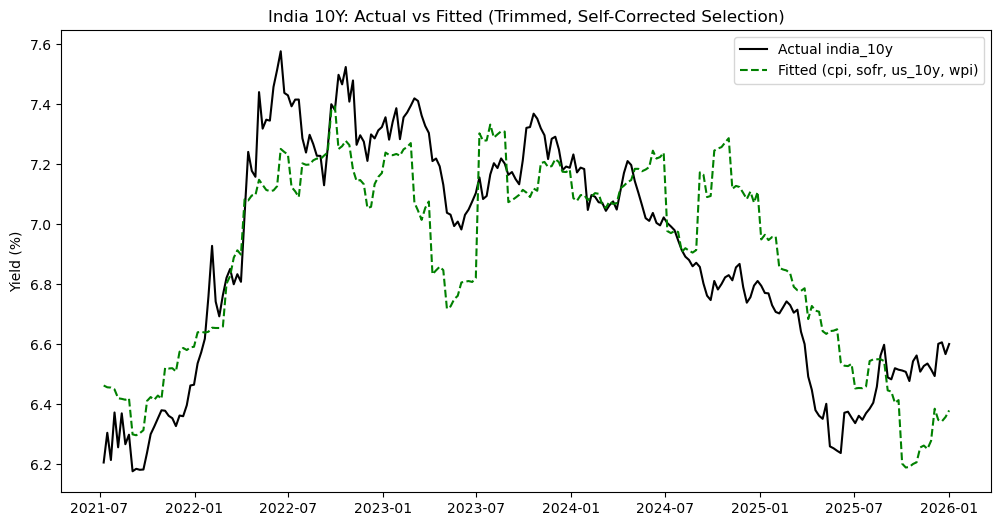

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_trimmed.index, y_trimmed, label='Actual india_10y', color='black')
plt.plot(y_trimmed.index, model_final.fittedvalues, label=f'Fitted ({", ".join(selected_vars)})', color='green', linestyle='--')
plt.legend()
plt.title('India 10Y: Actual vs Fitted (Trimmed, Self-Corrected Selection)')
plt.ylabel('Yield (%)')
plt.show()

In [138]:
backward_vars = list(final_vars_backward_trimmed.columns)
ladder_vars = selected_vars  # from cell 129
 
print("Backward final vars:", sorted(backward_vars))
print("Ladder   final vars:", sorted(ladder_vars))
print("Same variable set?  ", sorted(backward_vars) == sorted(ladder_vars))
print()
 
X_backward = weekly_matrix_trimmed[backward_vars]
X_ladder   = weekly_matrix_trimmed[ladder_vars]
 
print("X_backward shape:", X_backward.shape)
print("X_ladder shape:  ", X_ladder.shape)
print("Same row index?  ", X_backward.index.equals(X_ladder.index))
print()
 
# Reorder columns to match, then compare values directly
X_ladder_reordered = X_ladder[backward_vars]
print("Values identical (allowing column reorder)?",
      X_backward.equals(X_ladder_reordered))
print()
 
# Refit both explicitly and compare coefficients side by side
X_b = sm.add_constant(X_backward)
X_l = sm.add_constant(X_ladder_reordered)
model_b = sm.OLS(y_trimmed, X_b).fit()
model_l = sm.OLS(y_trimmed, X_l).fit()
 
import pandas as pd
compare = pd.DataFrame({
    "backward_coef": model_b.params,
    "ladder_coef":   model_l.params,
    "diff":          model_b.params - model_l.params,
})
print(compare)
print()
print(f"R² backward: {model_b.rsquared:.6f}")
print(f"R² ladder:   {model_l.rsquared:.6f}")
 

Backward final vars: ['cpi', 'sofr', 'us_10y', 'wpi']
Ladder   final vars: ['cpi', 'sofr', 'us_10y', 'wpi']
Same variable set?   True

X_backward shape: (235, 4)
X_ladder shape:   (235, 4)
Same row index?   True

Values identical (allowing column reorder)? True

        backward_coef  ladder_coef  diff
const        5.111939     5.111939   0.0
us_10y       0.099839     0.099839   0.0
sofr         0.163391     0.163391   0.0
cpi          0.135393     0.135393   0.0
wpi          0.038762     0.038762   0.0

R² backward: 0.718675
R² ladder:   0.718675


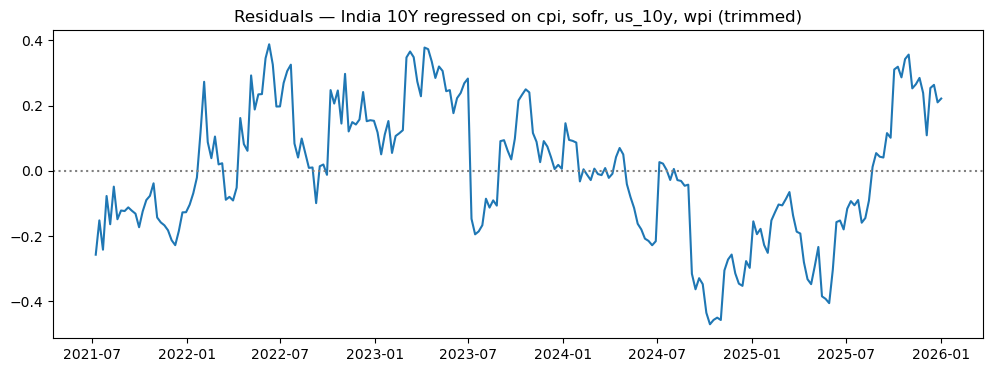

In [130]:
residuals_final = model_final.resid

plt.figure(figsize=(12,4))
plt.plot(residuals_final.index, residuals_final)
plt.axhline(0, color='gray', linestyle=':')
plt.title(f'Residuals — India 10Y regressed on {", ".join(selected_vars)} (trimmed)')
plt.show()

Walk-forward RMSE (trimmed, self-corrected variables): 0.2711


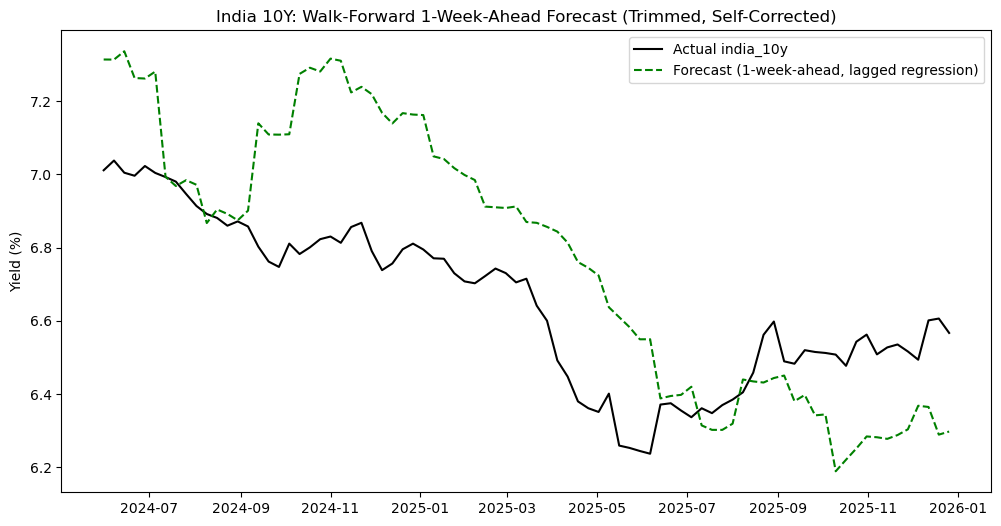

In [131]:
import numpy as np
from sklearn.metrics import mean_squared_error

X_lagged_final = weekly_matrix_trimmed[selected_vars].shift(1).dropna()
y_aligned_final = weekly_matrix_trimmed['india_10y'].reindex(X_lagged_final.index)

window = 150
predictions = []
actuals = []
dates = []

for start in range(0, len(X_lagged_final) - window - 1):
    X_train = sm.add_constant(X_lagged_final.iloc[start:start+window])
    y_train = y_aligned_final.iloc[start:start+window]
    X_test = sm.add_constant(X_lagged_final.iloc[[start+window]], has_constant='add')
    y_test = y_aligned_final.iloc[start+window]
    
    m = sm.OLS(y_train, X_train).fit()
    pred = m.predict(X_test).values[0]
    
    predictions.append(pred)
    actuals.append(y_test)
    dates.append(y_aligned_final.index[start+window])

rmse_final = np.sqrt(mean_squared_error(actuals, predictions))
print(f"Walk-forward RMSE (trimmed, self-corrected variables): {rmse_final:.4f}")

plt.figure(figsize=(12,6))
plt.plot(dates, actuals, label='Actual india_10y', color='black')
plt.plot(dates, predictions, label='Forecast (1-week-ahead, lagged regression)', color='green', linestyle='--')
plt.legend()
plt.title('India 10Y: Walk-Forward 1-Week-Ahead Forecast (Trimmed, Self-Corrected)')
plt.ylabel('Yield (%)')
plt.show()

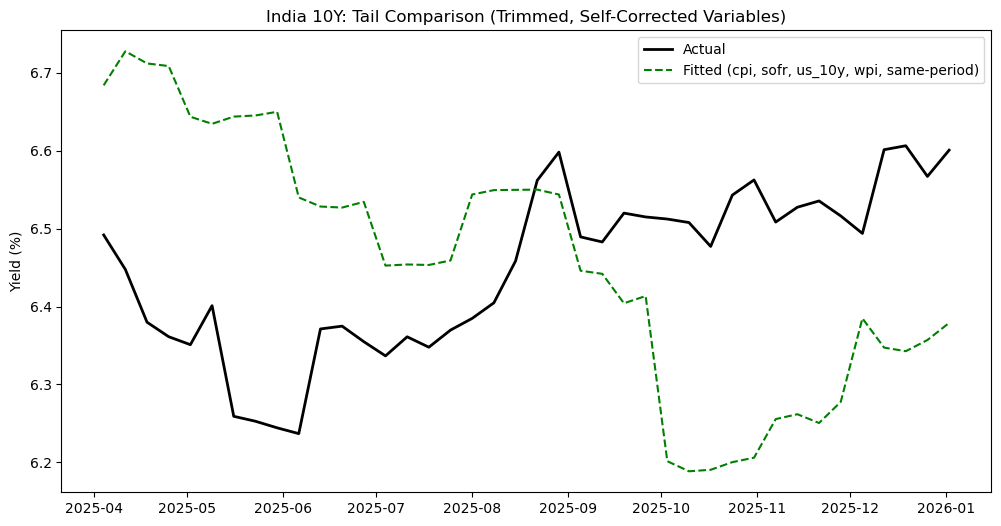

In [132]:
tail_start = weekly_matrix_trimmed.index[-40]

plt.figure(figsize=(12,6))
plt.plot(y_trimmed[y_trimmed.index >= tail_start].index, y_trimmed[y_trimmed.index >= tail_start], 
         label='Actual', color='black', linewidth=2)
plt.plot(y_trimmed[y_trimmed.index >= tail_start].index, model_final.fittedvalues[y_trimmed.index >= tail_start], 
         label=f'Fitted ({", ".join(selected_vars)}, same-period)', color='green', linestyle='--')
plt.legend()
plt.title('India 10Y: Tail Comparison (Trimmed, Self-Corrected Variables)')
plt.ylabel('Yield (%)')
plt.show()

In [133]:
# most recent known week's predictor values
last_known = weekly_matrix_trimmed[selected_vars].iloc[[-1]]
X_next = sm.add_constant(last_known, has_constant='add')

next_forecast = model_final.predict(X_next)
next_date = weekly_matrix_trimmed.index[-1] + pd.Timedelta(weeks=1)

print(f"Forecast for {next_date.date()}: india_10y ≈ {next_forecast.values[0]:.4f}")

Forecast for 2026-01-09: india_10y ≈ 6.3790


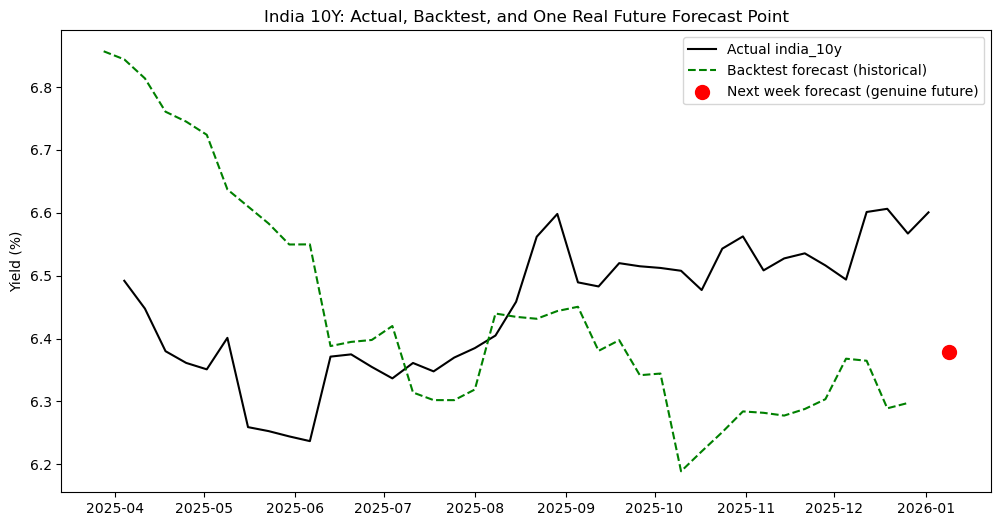

In [134]:
# Actual data stops here
plt.figure(figsize=(12,6))
plt.plot(y_trimmed.index[-40:], y_trimmed.iloc[-40:], label='Actual india_10y', color='black')

# Walk-forward backtest forecast (historical, for validation)
plt.plot(dates[-40:], predictions[-40:], label='Backtest forecast (historical)', color='green', linestyle='--')

# One real step into the genuine future
last_known = weekly_matrix_trimmed[selected_vars].iloc[[-1]]
X_next = sm.add_constant(last_known, has_constant='add')
next_forecast = model_final.predict(X_next)
next_date = weekly_matrix_trimmed.index[-1] + pd.Timedelta(weeks=1)

plt.scatter([next_date], [next_forecast.values[0]], color='red', s=100, zorder=5, label='Next week forecast (genuine future)')

plt.legend()
plt.title('India 10Y: Actual, Backtest, and One Real Future Forecast Point')
plt.ylabel('Yield (%)')
plt.show()

In [135]:
# full weekly_matrix should already have the corrected cpi_daily in it
holdout = weekly_matrix[weekly_matrix.index > '2025-12-31']
print(f"Holdout period: {holdout.index.min().date()} to {holdout.index.max().date()}, {len(holdout)} weeks")
print(holdout[selected_vars + ['india_10y']].head(10))

Holdout period: 2026-01-02 to 2026-07-03, 27 weeks
             cpi  sofr  us_10y       wpi  india_10y
trade_date                                         
2026-01-02  2.74  3.75    4.19  1.677419   6.611988
2026-01-09  2.74  3.64    4.18  1.677419   6.646284
2026-01-16  2.74  3.65    4.24  1.677419   6.676431
2026-01-23  2.74  3.65    4.24  1.677419   6.664668
2026-01-30  2.74  3.68    4.26  1.677419   6.705268
2026-02-06  3.21  3.64    4.22  2.259522   6.709022
2026-02-13  3.21  3.66    4.04  2.259522   6.673177
2026-02-20  3.21  3.66    4.08  2.259522   6.716637
2026-02-27  3.21  3.68    3.97  2.259522   6.683367
2026-03-06  3.40  3.65    4.15  3.875969   6.676238


In [136]:
X_holdout = sm.add_constant(holdout[selected_vars], has_constant='add')
holdout_predictions = model_final.predict(X_holdout)

holdout_actuals = holdout['india_10y']

rmse_holdout = np.sqrt(mean_squared_error(holdout_actuals, holdout_predictions))
print(f"\nOut-of-sample RMSE (trained through Dec 2025, tested on Jan-Jul 2026): {rmse_holdout:.4f}")


Out-of-sample RMSE (trained through Dec 2025, tested on Jan-Jul 2026): 0.1248


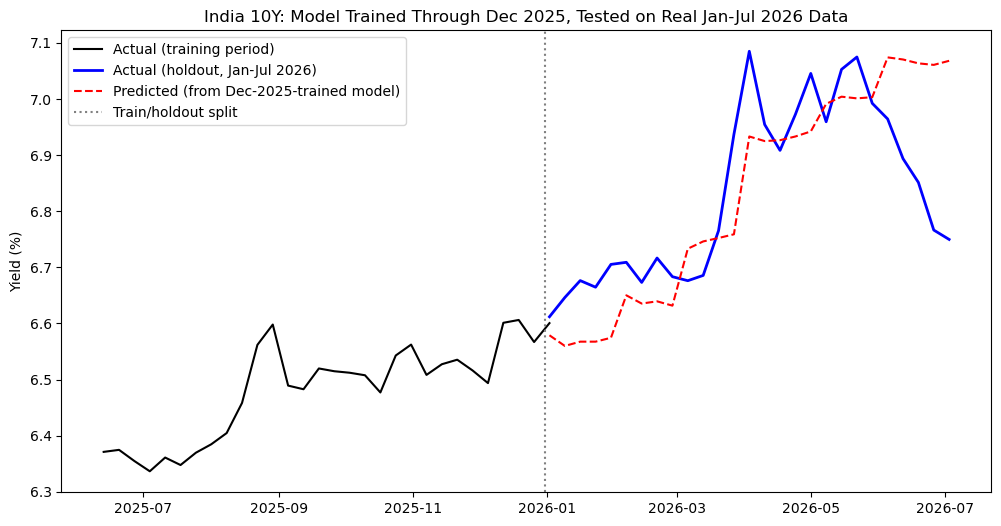

In [137]:
plt.figure(figsize=(12,6))

# training period (last 30 weeks for context)
plt.plot(y_trimmed.index[-30:], y_trimmed.iloc[-30:], label='Actual (training period)', color='black')

# genuine holdout — real actual data the model never saw
plt.plot(holdout_actuals.index, holdout_actuals, label='Actual (holdout, Jan-Jul 2026)', color='blue', linewidth=2)

# model's predictions for that same holdout period
plt.plot(holdout_predictions.index, holdout_predictions, label='Predicted (from Dec-2025-trained model)', color='red', linestyle='--')

plt.axvline(pd.Timestamp('2025-12-31'), color='gray', linestyle=':', label='Train/holdout split')
plt.legend()
plt.title('India 10Y: Model Trained Through Dec 2025, Tested on Real Jan-Jul 2026 Data')
plt.ylabel('Yield (%)')
plt.show()

In [139]:

# fitted coefficients, and compares the prediction to the actual yield.

import pandas as pd

# --- pick a date: swap this for any Friday in June 2026 present in your weekly index ---
target_date = pd.Timestamp('2026-06-19')  # change to any June 2026 week-end date you like

# find the closest available week to that date in the holdout set
row = holdout.loc[[holdout.index[holdout.index.get_indexer([target_date], method='nearest')[0]]]]
actual_date = row.index[0]

print(f"Checking week of: {actual_date.date()}")
print("\nReal predictor values that week:")
print(row[selected_vars])

# build the same design matrix shape the model was fit on (const + 4 vars)
X_check = sm.add_constant(row[selected_vars], has_constant='add')
predicted_yield = model_final.predict(X_check).values[0]
actual_yield = row['india_10y'].values[0]

error = predicted_yield - actual_yield

print(f"\nPredicted india_10y: {predicted_yield:.4f}")
print(f"Actual india_10y:    {actual_yield:.4f}")
print(f"Error (pred - actual): {error:+.4f}  ({error/actual_yield*100:+.2f}%)")

# --- optional: do this for every week in June 2026 at once ---
june_2026 = holdout[(holdout.index >= '2026-06-01') & (holdout.index <= '2026-06-30')]
X_june = sm.add_constant(june_2026[selected_vars], has_constant='add')
june_pred = model_final.predict(X_june)

june_compare = pd.DataFrame({
    'actual': june_2026['india_10y'],
    'predicted': june_pred,
})
june_compare['error'] = june_compare['predicted'] - june_compare['actual']
print("\nAll June 2026 weeks:")
print(june_compare)

Checking week of: 2026-06-19

Real predictor values that week:
             cpi  sofr  us_10y       wpi
trade_date                              
2026-06-19  4.38  3.62    4.46  8.300908

Predicted india_10y: 7.0635
Actual india_10y:    6.8513
Error (pred - actual): +0.2121  (+3.10%)

All June 2026 weeks:
              actual  predicted     error
trade_date                               
2026-06-05  6.964413   7.074097  0.109684
2026-06-12  6.893714   7.070376  0.176662
2026-06-19  6.851337   7.063478  0.212141
2026-06-26  6.766475   7.060755  0.294280


In [140]:


june_vars = holdout.loc[june_2026.index, selected_vars]
print("Raw predictor values, June 2026:")
print(june_vars)
print()

# week-over-week change in each predictor
print("Week-over-week change in each predictor:")
print(june_vars.diff())
print()

# each predictor's contribution to the prediction = coefficient * value
coefs = model_final.params.drop('const')
contributions = june_vars * coefs
contributions['const'] = model_final.params['const']
contributions['predicted_total'] = contributions.sum(axis=1)

print("Each variable's contribution to the predicted yield (coef * value):")
print(contributions.round(3))
print()

# how much each contribution changed week-to-week -- this shows what's PUSHING
# the prediction up or down each week
print("Week-over-week change in each variable's contribution:")
print(contributions.drop(columns='predicted_total').diff().round(3))

Raw predictor values, June 2026:
             cpi  sofr  us_10y       wpi
trade_date                              
2026-06-05  4.38  3.63    4.55  8.300908
2026-06-12  4.38  3.65    4.48  8.300908
2026-06-19  4.38  3.62    4.46  8.300908
2026-06-26  4.38  3.64    4.40  8.300908

Week-over-week change in each predictor:
            cpi  sofr  us_10y  wpi
trade_date                        
2026-06-05  NaN   NaN     NaN  NaN
2026-06-12  0.0  0.02   -0.07  0.0
2026-06-19  0.0 -0.03   -0.02  0.0
2026-06-26  0.0  0.02   -0.06  0.0

Each variable's contribution to the predicted yield (coef * value):
              cpi   sofr  us_10y    wpi  const  predicted_total
trade_date                                                     
2026-06-05  0.593  0.593   0.454  0.322  5.112            7.074
2026-06-12  0.593  0.596   0.447  0.322  5.112            7.070
2026-06-19  0.593  0.591   0.445  0.322  5.112            7.063
2026-06-26  0.593  0.595   0.439  0.322  5.112            7.061

Week-over-week 